<a href="https://colab.research.google.com/github/valleyofdawn/TreeTag/blob/main/TreeTag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Single cell annotation pipline

In [ ]:
ig.Graph.Load()

## Prep

### Install missing libraries

In [31]:
!pip install google-cloud-storage scanpy anndata mygene harmonypy igraph leidenalg scikit-misc --quiet

### load libraries

In [32]:
from anndata import AnnData # for rading 10x format
from google.cloud import storage
from google.colab import auth, drive
from hashlib import blake2b
from pathlib import Path # needed for multiple file input
from scipy import sparse as sp
from scipy.io import mmread
from scipy.sparse import issparse, csc_matrix, coo_matrix, dia_matrix, csr_matrix # for TreeTag
from scipy.stats import zscore, pearsonr, ttest_ind, ttest_rel # for leave-one-out marker pruning
from sklearn.decomposition import PCA
from sklearn.metrics import auc
from sklearn.preprocessing import StandardScaler, minmax_scale
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from typing import Literal, Sequence, Tuple, Optional

import anndata as ad # needed throughout
import colorsys, gc, glob, gzip, h5py, harmonypy as hm, igraph as ig, io, matplotlib.pyplot as plt
import mygene as mg, numpy as np, openai, os, pandas as pd, re, requests, scanpy as sc, scipy.sparse as sp, seaborn as sns
import tarfile, textwrap, time, yaml


### Set variables

In [33]:
sc.settings.verbosity = 0             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
set4 =  ['darkgreen', 'cornflowerblue', 'thistle', 'plum', 'orange',
    'magenta', 'lightgreen', 'tan', 'slateblue', 'gray', 'turquoise',
    'coral', 'lightgray', 'green', 'pink', 'gold', 'peru',
    'red', 'olive', 'lime', 'teal', 'violet',
    'orchid', 'beige', 'lightgrey', 'darkorange',
    'lightgreen', 'blue', 'wheat','darkred']
pastels= [
    '#aacc70', '#7080cc', '#78cc70', '#70cccc', '#cc7089', '#cc70bb',
    '#91cc70', '#c3cc70', '#cc8970', '#cc70a2', '#aa70cc', '#cc7070',
    '#70cc99', '#9170cc', '#7870cc', '#7099cc', '#ccbb70', '#70cc80',
    '#cca270', '#70ccb2', '#c370cc', '#70b2cc'
]


plt.rcParams['figure.figsize'] = (6, 6)
os.environ['LOKY_MAX_CPU_COUNT'] = '12'
pd.set_option('display.float_format', '{:.2e}'.format)

### Connect

In [34]:
from google.colab import userdata
userdata.get('openai_client')
# os.chdir('/content/')
# print('Current working directory:', os.getcwd())
auth.authenticate_user()
client = storage.Client(project='Scanpy for Biolojic')
bucket = client.bucket('single_cell_h5ad_datasets')
# from google.colab import drive
# drive.mount('/content/drive')

### Function definitions

#### Fetch

In [35]:
def fetch(filenames: list):
  """Downloads a list of files from the specified GCS bucket.

  Args:
    filenames: A list of strings, where each string is a filename in the GCS
      bucket.
  """
  if isinstance(filenames, str):
    filenames = [filenames]
  for filename in filenames:
    # Extract only the base filename
    base_filename = os.path.basename(filename)
    blob = bucket.blob(filename)
    # Download to /content/ with just the base filename
    blob.download_to_filename(f'/content/{base_filename}')

#### Palette from graph

In [36]:
import colorsys, hashlib

def palette_from_graph(G, root, saturation=0.65, brightness=0.92,
                       leaves_only=False, order="name"):
    """
    Build a {node_name: '#RRGGBB'} palette for an igraph tree.

    Modes:
      - 'name'  : hierarchical split; siblings sorted case-insensitively by name
      - 'size'  : hierarchical split; siblings by subtree leaf count (desc), tie→name
      - 'ID'    : hierarchical split; siblings by vertex index (ascending)
      - 'random': GLOBAL leaf palette — assign evenly spaced hues across all leaves
                  (deterministic hash order by (root, leaf_name)); internal nodes uncolored.

    Args:
      leaves_only: if True, omit internal nodes in hierarchical modes too.
      saturation/brightness: HSV S,V used for all assigned colors.
    """
    r_idx = G.vs.find(name=root).index

    def hsv_hex(h, s, v):
        r, g, b = colorsys.hsv_to_rgb(h % 1.0, max(0, min(1, s)), max(0, min(1, v)))
        return "#{:02X}{:02X}{:02X}".format(int(round(r*255)),
                                            int(round(g*255)),
                                            int(round(b*255)))

    # subtree leaf counts (used by hierarchical modes)
    cnt = [0] * G.vcount()
    def dfs_count(u):
        kids = G.successors(u)
        cnt[u] = 1 if not kids else sum(dfs_count(v) for v in kids)
        return cnt[u]
    dfs_count(r_idx)

    # --- GLOBAL randomized leaf palette (no hierarchical splitting) ---
    if order == "random":
        # collect descendants of root and identify leaves
        stack, seen, desc = [r_idx], set(), []
        while stack:
            u = stack.pop()
            if u in seen: continue
            seen.add(u); desc.append(u)
            stack.extend(G.successors(u))
        leaves = [i for i in desc if not G.successors(i)]
        L = len(leaves)
        if L == 0:
            return {}

        # deterministic order via hash(root, leaf_name); evenly spaced hues in that order
        def key_hash(vid):
            b = (G.vs[r_idx]["name"] + "\0" + G.vs[vid]["name"]).casefold().encode("utf-8")
            return int.from_bytes(hashlib.blake2s(b, digest_size=8).digest(), "little")

        leaves_sorted = sorted(leaves, key=key_hash)
        out = {G.vs[vid]["name"]: hsv_hex((rank + 0.5) / L, saturation, brightness)
               for rank, vid in enumerate(leaves_sorted)}
        # internal nodes intentionally left uncolored in this mode
        return out

    # --- Hierarchical splitting (name/size/ID) ---
    intervals = {}
    def assign(u_idx, h0, h1):
        intervals[u_idx] = (h0, h1)
        kids = G.successors(u_idx)
        if not kids:
            return
        if order == "size":
            kids = sorted(kids, key=lambda k: (-cnt[k], G.vs[k]["name"].casefold()))
        elif order == "name":
            kids = sorted(kids, key=lambda k: G.vs[k]["name"].casefold())
        elif order in ("ID", "id"):
            kids = sorted(kids)  # vertex indices
        else:
            raise ValueError("order must be 'name', 'size', 'ID', or 'random'")
        total = sum(cnt[k] for k in kids) or 1
        cur = h0
        for k in kids:
            frac = cnt[k] / total
            nxt = cur + (h1 - h0) * frac
            assign(k, cur, nxt)
            cur = nxt

    assign(r_idx, 0.0, 1.0)

    out = {}
    for vid, (h0, h1) in intervals.items():
        if leaves_only and G.outdegree(vid) > 0:
            continue
        out[G.vs[vid]["name"]] = hsv_hex((h0 + h1) / 2.0, saturation, brightness)
    return out


#### Show Markers

In [37]:
def markers(cell_type: str,
            sign: str = "pos",
            markers_yaml: str = "markers.yaml",
            tree_yaml: str = "tree.yaml",
            adata=None):
    """
    Return the marker list for a given cell_type and sign ('pos' or 'neg'),
    using the new graph structure where markers are stored on nodes.
    If `adata` is provided, markers are filtered to genes present in the data.
    """
    if sign not in {"pos", "neg"}:
        raise ValueError("sign must be 'pos' or 'neg'")

    # Build graph with markers attached (filtered if adata is given)
    G = init_tree(tree_yaml, markers_yaml, root="root", adata=adata)  # use your actual root name

    # Look up the node
    try:
        v = G.vs.find(name=cell_type)
    except ValueError:
        print(f"Cell type '{cell_type}' not found in the tree. Skipping.")
        return []

    attr = "pos_markers" if sign == "pos" else "neg_markers"
    lst = list(v[attr]) if v[attr] is not None else []

    # Extra safety: if adata was provided, ensure presence in the matrix
    if adata is not None:
        var_names = adata.raw.var_names if getattr(adata, "raw", None) is not None else adata.var_names
        present = [g for g in lst if g in var_names]
        missing = [g for g in lst if g not in var_names]
        for g in missing:
            print(f"Marker '{g}' not found in data. Skipping.")
        return present

    return lst


#### Subset data

In [38]:
def subset(adata, column: str, value) -> 'AnnData':
    if adata.raw is None:
        raise ValueError('AnnData.raw is not set. Cannot subset raw data.')

    if column not in adata.obs.columns:
        raise KeyError(f"Column '{column}' not found in adata.obs.")

    mask = adata.obs[column] == value
    if mask.sum() == 0:
        raise ValueError(f"No cells found where adata.obs['{column}'] == {value!r}")

    adata_sub = adata[mask].copy()
    adata_sub.raw = adata.raw.to_adata()[mask].copy()
    return adata_sub


#### Convert to HGNC

In [39]:
def convert(adata):
    """
    Convert var_names (and raw.var_names) from Ensembl or Entrez IDs to official gene symbols.
    Gene symbols and aliases are left unchanged.
    Stores original names in adata.var['original_gene'] and, if raw exists, in adata.raw.var['original_gene'].
    """
    import re
    import mygene as mg
    mg_client = mg.MyGeneInfo()

    sample = adata.var_names[:100]

    # ID patterns
    ensembl_pat = re.compile(r'ENSG\d{9}')
    entrez_pat = re.compile(r'^\d+$')

    n_ensembl = sum(bool(ensembl_pat.match(g)) for g in sample)
    n_entrez = sum(bool(entrez_pat.match(g)) for g in sample)

    def get_user_choice():
        print("Ambiguous gene ID format. Please choose ID type to convert from:")
        print("1: Ensembl")
        print("2: Entrez")
        print("0: Cancel")
        while True:
            choice = input("Enter 1, 2, or 0: ").strip()
            if choice in ('0', '1', '2'):
                return choice

    if n_ensembl > 50:
        print(f'🔄 Detected Ensembl IDs in {n_ensembl}/100 sampled genes — converting to symbols.')
        scopes = 'ensembl.gene'
    elif n_entrez > 50:
        print(f'🔄 Detected Entrez IDs in {n_entrez}/100 sampled genes — converting to symbols.')
        scopes = 'entrezgene'
    elif max(n_ensembl, n_entrez) < 10:
        print('❌ Less than 10% of sampled genes matched Ensembl or Entrez formats. No conversion performed.')
        return adata
    else:
        choice = get_user_choice()
        if choice == '0':
            print('🚫 Conversion cancelled by user.')
            return adata
        scopes = {'1': 'ensembl.gene', '2': 'entrezgene'}[choice]
        print(f'🔄 Converting using selected scope: {scopes}')

    # Run conversion
    results = mg_client.querymany(adata.var_names.tolist(), scopes=scopes, fields='symbol', species='human')
    mapping = {entry['query']: entry.get('symbol', entry['query']) for entry in results}

    # Store original gene names
    adata.var['original_gene'] = adata.var_names.copy()

    # Rename genes
    new_names = adata.var_names.map(lambda g: mapping.get(g, g))
    adata.var_names = new_names
    adata.var_names_make_unique()

    # Update raw if available
    if adata.raw is not None:
        adata.raw.var['original_gene'] = adata.raw.var_names.copy()
        adata.raw.var.index = adata.var_names.copy()

    num_changed = (adata.var['original_gene'] != adata.var_names).sum()
    print(f"✅ Conversion complete. {num_changed} gene names were changed.")
    return adata


In [40]:
def convert(adata, organism: str = "hsapiens",
            prefer_var_cols = ("feature_name", "gene_symbols", "SYMBOL")):
    """
    Rename adata.var_names (and raw.var) to official gene symbols.

    Strategy:
      1) If a symbols column exists in `adata.var` (e.g. 'feature_name'), use it directly.
      2) Otherwise, batch-convert current var_names via g:Profiler.

    Stores originals in adata.var['original_gene'] and, if raw exists, adata.raw.var['original_gene'].
    """
    import numpy as np

    # 1) Fast path: use an existing symbols column if available
    for col in prefer_var_cols:
        if col in adata.var.columns:
            vals = adata.var[col].astype(str)
            if vals.nunique() > 0:
                orig = adata.var_names.astype(str)
                adata.var["original_gene"] = orig
                adata.var_names = vals
                adata.var_names_make_unique()
                if adata.raw is not None:
                    adata.raw.var["original_gene"] = adata.raw.var_names.astype(str)
                    adata.raw.var.index = adata.var_names
                changed = int(np.sum(orig.values != adata.var_names.values))
                print(f"✅ Using symbols from adata.var['{col}']; renamed {changed} genes.")
                return adata

    # 2) Fallback: g:Profiler batch conversion
    try:
        from gprofiler import GProfiler
    except Exception as e:
        raise ImportError("gprofiler-official is required for ID conversion. "
                          "Install with `pip install gprofiler-official`.") from e

    gp = GProfiler(return_dataframe=True)
    queries = adata.var_names.astype(str).tolist()
    df = gp.convert(organism=organism, query=queries)

    if df is None or df.empty or "incoming" not in df.columns:
        print("❌ g:Profiler returned no mappings; leaving var_names unchanged.")
        return adata

    sym_col = "name" if "name" in df.columns else ("converted" if "converted" in df.columns else None)
    if sym_col is None:
        print("❌ g:Profiler response missing expected symbol column; leaving unchanged.")
        return adata

    mapping = dict(zip(df["incoming"].astype(str), df[sym_col].astype(str)))

    orig = adata.var_names.astype(str)
    new = orig.map(lambda g: mapping.get(g, g))
    changed = int((new.values != orig.values).sum())

    adata.var["original_gene"] = orig
    adata.var_names = new
    adata.var_names_make_unique()

    if adata.raw is not None:
        adata.raw.var["original_gene"] = adata.raw.var_names.astype(str)
        adata.raw.var.index = adata.var_names

    print(f"✅ Converted var_names via g:Profiler ({organism}). {changed} names changed.")
    return adata


#### Enrich

In [41]:
def enrich (genes, type = 'cell', description='Example gene list'):
    if type == 'cell':
      library_list = [
      'Azimuth_2023',
      'CellMarker_2024',
      'HuBMAP_ASCTplusB_augmented_2022',
      'PanglaoDB_Augmented_2021',
      'Tabula_Sapiens']
    else:
      library_list = [
      'Reactome_Pathways_2024',
      'WikiPathways_2024_Human',
      'BioPlanet_2019',
      'KEGG_2021_Human',
      'Elsevier_Pathway_Collection']

    combined_results = []

    for library_name in library_list:
        time.sleep(1)  # Avoid rate limiting
        payload = {'list': '\n'.join(genes), 'description': description}
        response = requests.post('https://maayanlab.cloud/Enrichr/addList', files=payload)

        if response.status_code != 200:
            raise Exception('Error analyzing gene list:', response.text)

        user_list_id = response.json().get('userListId')
        results_url = f'https://maayanlab.cloud/Enrichr/enrich?userListId={user_list_id}&backgroundType={library_name}'
        enrichment_response = requests.get(results_url)

        if enrichment_response.status_code != 200:
            raise Exception('Error fetching enrichment results:', enrichment_response.text)

        enrichment_data = enrichment_response.json().get(library_name, [])
        if not enrichment_data:
            continue

        # Convert to dataframe
        results_df = pd.DataFrame([
            {
                'Library': library_name,
                'Term': row[1],
                'PValue': float(row[2]),
                'AdjustedPValue': float(row[6]),
                'OverlappingGenes': ', '.join(row[5])
            }
            for row in enrichment_data
        ])

        combined_results.append(results_df)

    if not combined_results:
        return pd.DataFrame()

    combined_df = pd.concat(combined_results, ignore_index=True)

    # Filter results
    combined_df = combined_df[combined_df['AdjustedPValue'] < 0.01]
    combined_df = combined_df[combined_df['OverlappingGenes'].str.split(', ').map(len) > 3]

    return combined_df

#### ChatGPT

In [42]:
def ChatGPT(gene_set, cell_category, tissue, model='gpt-4o'):
    # Construct the prompt
    prompt = f'''
You are a biomedical expert. Based on your knowledge of gene expression and cellular specialization,
assess which {cell_category} in the {tissue} are most likely to differentially express the following gene set:

{', '.join(gene_set)}

Consider the gene set as a whole. Do not assess each gene individually.

List only the relevant cell types, each with a summary likelihood:
'very likely', 'possibly', or 'unlikely'.

Present your answer in this format:

- Cell_Type_A: very likely
- Cell_Type_B: possibly
'''

    # Query ChatGPT
    response = openai_client.chat.completions.create(
        model=model,
        messages=[{'role': 'user', 'content': prompt}],
        temperature=0.3
    )

    # Extract and parse text response
    text = response.choices[0].message.content
    lines = text.splitlines()

    # Filter and parse into tuples
    parsed = []
    for line in lines:
        if ':' in line:
            cell_type, likelihood = line.split(':', 1)
            parsed.append((cell_type.strip(' -*•'), likelihood.strip().lower()))

    # Sort by likelihood level
    likelihood_order = {'very likely': 0, 'possibly': 1, 'unlikely': 2}
    parsed_sorted = sorted(parsed, key=lambda x: likelihood_order.get(x[1], 3))

    # Convert to DataFrame
    df = pd.DataFrame(parsed_sorted, columns=['Cell Type', 'Likelihood'])
    return df

#### DGE computation

In [43]:
def DGE(
    adata,
    target_group,
    reference_group,
    groupby,
    min_pct=None,
    min_log2fc=None,
    min_delta_pct=None,
    direction='pos',  # 'pos', 'neg', or 'both'
    n_genes=200,
    n_sample=None,
    return_df=False,
):
    """
    Differential Gene Expression for log-transformed data with optional Δpct and fold-change filters.
    Performs Welch's t-test and FDR correction. Assumes adata.raw is log-normalized data.
    """

    if direction not in ('pos', 'neg', 'both'):
        raise ValueError("direction must be one of 'pos', 'neg', or 'both'")
    if adata.raw is None:
        raise ValueError("`adata.raw` must be set before running DGE().")
    if isinstance(target_group, str):
        target_group = [target_group]

    labels = adata.obs[groupby].values
    tmask = np.isin(labels, target_group)
    rmask = ~tmask if reference_group == 'rest' else (labels == reference_group)

    def subsample(mask):
        idx = np.where(mask)[0]
        if n_sample is not None and len(idx) > n_sample:
            return np.random.choice(idx, size=n_sample, replace=False)
        return idx

    t_idx = subsample(tmask)
    r_idx = subsample(rmask)
    X = adata.raw.X
    var_names = adata.raw.var_names
    X_t = X[t_idx]
    X_r = X[r_idx]
    nt, nr = len(t_idx), len(r_idx)

    # Means and % expressing
    if sp.issparse(X):
        mean_t = X_t.mean(axis=0).A1
        mean_r = X_r.mean(axis=0).A1
        pct_t = X_t.getnnz(axis=0) / nt
        pct_r = X_r.getnnz(axis=0) / nr
        X_t_dense = X_t.toarray()
        X_r_dense = X_r.toarray()
    else:
        mean_t = X_t.mean(axis=0)
        mean_r = X_r.mean(axis=0)
        pct_t = (X_t > 0).mean(axis=0)
        pct_r = (X_r > 0).mean(axis=0)
        X_t_dense = X_t
        X_r_dense = X_r

    log2fc = mean_t - mean_r
    delta_pct = pct_t - pct_r

    # Filter before statistical test
    if direction == 'both':
        fc_mask = np.abs(log2fc) >= (min_log2fc or 0)
        dp_mask = np.abs(delta_pct) >= (min_delta_pct or 0)
    elif direction == 'pos':
        fc_mask = log2fc >= (min_log2fc or 0)
        dp_mask = delta_pct >= (min_delta_pct or 0)
    else:  # 'neg'
        fc_mask = log2fc <= -(min_log2fc or 0)
        dp_mask = delta_pct <= -(min_delta_pct or 0)

    pct_mask = pct_t >= (min_pct or 0)
    keep_mask = np.logical_and.reduce([pct_mask, fc_mask, dp_mask])
    kept = np.where(keep_mask)[0]

    if kept.size == 0:
        print("No genes passed the filtering criteria.")
        return pd.DataFrame(columns=[
            'gene', 'mean_target', 'mean_ref',
            'pct_target', 'pct_ref', 'delta_pct',
            'log2fc', 'pval', 'pval_adj'
        ]) if return_df else []

    # Run t-tests only on filtered genes
    X_t_dense = X_t_dense[:, kept]
    X_r_dense = X_r_dense[:, kept]
    _, pvals = ttest_ind(X_t_dense, X_r_dense, axis=0, equal_var=False)
    pvals = np.asarray(pvals)

    # Adjust p-values
    adj_pvals = np.full_like(pvals, np.nan, dtype=np.float64)
    valid = ~np.isnan(pvals)
    if valid.sum() > 0:
        adj_pvals[valid] = multipletests(pvals[valid], method='fdr_bh')[1]
    else:
        print("All p-values are NaN — no FDR correction performed.")

    # Assemble results
    df = pd.DataFrame({
        'gene': var_names[kept],
        'mean_target': mean_t[kept],
        'mean_ref': mean_r[kept],
        'pct_target': pct_t[kept],
        'pct_ref': pct_r[kept],
        'delta_pct': delta_pct[kept],
        'log2fc': log2fc[kept],
        'pval': pvals,
        'pval_adj': adj_pvals,
    })

    # Sort genes
    if direction == 'both':
        df = df.sort_values('pval')
    elif direction == 'neg':
        df = df.sort_values(['log2fc', 'pval'], ascending=[True, True])
    else:
        df = df.sort_values(['log2fc', 'pval'], ascending=[False, True])

    return df if return_df else df['gene'].head(n_genes).tolist()


#### get subscores

In [44]:
def subscores(root_cell, adata,
              markers_yaml='markers.yaml',
              tree_yaml='tree.yaml',
              only_leaves: bool = "False"):

    G  = init_tree(tree_yaml, markers_yaml, root=root_cell)

    root_v = G.vs.find(name=root_cell)

    # all descendants (OUT reachability) and drop the root itself
    desc_idxs = G.subcomponent(root_v.index, mode='OUT')
    desc_idxs = [i for i in desc_idxs if i != root_v.index]
    if only_leaves:
      desc_idxs = [i for i in desc_idxs if G.outdegree(i) == 0]

    nodes = [G.vs[i]['name'] for i in desc_idxs]

    existing, missing = [], []
    for n in nodes:
        col = f"{n}_score"
        (existing if col in adata.obs else missing).append(col)

    if missing:
        print(f"Missing score columns: {missing}")
    return existing


#### Remove non-coding genes

In [45]:
def coding_genes(adata, gene_id_type=None, chunk_size=1000):
    """
    Filter an AnnData object to retain only protein-coding genes.

    Parameters
    ----------
    adata : AnnData
        Input object.
    gene_id_type : str or None
        'symbol' (e.g. 'CD3D') or 'ensembl.gene' (e.g. 'ENSG00000167286').
        If None, it is guessed based on var_names.
    chunk_size : int
        Number of genes per MyGeneInfo query batch (max 1000).

    Returns
    -------
    AnnData with only protein-coding genes in .X (and .raw, if present).
    """
    import pandas as pd
    import numpy as np

    is_backed = adata.isbacked

    # --- Guess gene ID type if not provided ---
    if gene_id_type is None:
        ens_like = sum(g.startswith("ENS") for g in adata.var_names)
        gene_id_type = "ensembl.gene" if ens_like / len(adata.var_names) > 0.5 else "symbol"
    print(f"🔍 Querying MyGeneInfo with scope: '{gene_id_type}'")

    gene_list = adata.var_names.tolist()
    mg_client = mg.MyGeneInfo()

    # --- Query in chunks ---
    out = []
    for i in range(0, len(gene_list), chunk_size):
        chunk = gene_list[i:i + chunk_size]
        try:
            res = mg_client.querymany(
                chunk,
                scopes=gene_id_type,
                fields='type_of_gene',
                species='human',
                as_dataframe=True,
                df_index=True
            )
            out.append(res)
        except Exception as e:
            print(f"⚠️  Query failed on chunk {i}: {e}")

    df = pd.concat(out)

    # --- Keep clean hits only ---
    df = df[~df['notfound'].fillna(False)]
    if 'type_of_gene' not in df.columns:
        raise ValueError("❌ MyGeneInfo returned no 'type_of_gene' annotations.")

    # --- Map gene ID to biotype and create mask ---
    # Create a mapping from the full list of genes in adata.var_names
    full_gene_biotype_map = pd.Series(df['type_of_gene'].values, index=df.index).reindex(adata.var_names)
    coding_mask = full_gene_biotype_map == 'protein-coding'

    # Apply the mask to filter adata
    if is_backed:
        # Apply mask directly in backed mode
        adata_filtered = adata[:, coding_mask]
        print(f"✅ Filtered from {adata.n_vars} to {adata_filtered.n_vars} protein-coding genes (in backed mode).")
    else:
        # Apply mask to in-memory object
        adata_filtered = adata[:, coding_mask].copy()
        print(f"✅ Filtered from {adata.n_vars} to {adata_filtered.n_vars} protein-coding genes.")


    # --- Filter .raw if present ---
    if adata.raw is not None and isinstance(adata.raw, ad.AnnData):
        if adata.raw.isbacked and is_backed:
            # Match raw var_names to filtered var_names and apply mask in backed mode
            raw_var_names = adata.raw.var_names
            raw_coding_mask = raw_var_names.isin(adata_filtered.var_names)
            adata_filtered.raw = adata.raw[:, raw_coding_mask]
        else:
            # Convert raw to memory if needed and apply mask
            raw_adata_mem = adata.raw.to_adata() if adata.raw.isbacked else adata.raw
            raw_var_names = raw_adata_mem.var_names
            raw_coding_mask = raw_var_names.isin(adata_filtered.var_names)
            adata_filtered.raw = raw_adata_mem[:, raw_coding_mask].copy()


    return adata_filtered

#### QC computation

In [46]:
def compute_qc (adata):
    if adata.raw is None:
        raise ValueError('adata.raw is not set.')

    X = adata.raw.X
    gene_names = adata.raw.var_names

    # Define gene masks
    mt_mask = gene_names.str.startswith('MT-')
    ribo_mask = gene_names.str.startswith(('RPS', 'RPL'))
    hsp_mask = gene_names.str.startswith(('HSP', 'DNAJ'))

    # Convert sparse to dense row sums if needed
    row_sum = X.sum(axis=1).A1 if sp.issparse(X) else X.sum(axis=1)
    gene_count = (X > 0).sum(axis=1).A1 if sp.issparse(X) else (X > 0).sum(axis=1)

    mt_sum = X[:, mt_mask].sum(axis=1).A1 if sp.issparse(X) else X[:, mt_mask].sum(axis=1)
    ribo_sum = X[:, ribo_mask].sum(axis=1).A1 if sp.issparse(X) else X[:, ribo_mask].sum(axis=1)
    hsp_sum = X[:, hsp_mask].sum(axis=1).A1 if sp.issparse(X) else X[:, hsp_mask].sum(axis=1)

    # Assign to .obs
    adata.obs['total_counts'] = row_sum
    adata.obs['n_genes_by_counts'] = gene_count
    adata.obs['pct_counts_mt'] = (mt_sum / row_sum) * 100
    adata.obs['pct_counts_ribo'] = (ribo_sum / row_sum) * 100
    adata.obs['pct_counts_hsp'] = (hsp_sum / row_sum) * 100

    return adata


#### Restore from raw

In [47]:
def restore_from_raw(adata):
  # Step 1: Rebuild AnnData with full expression from .raw
  adata_full = ad.AnnData(
      X = adata.raw.X,
      obs = adata.obs.copy(),
      var = adata.raw.var.copy()
  )
  adata_full.var_names = adata.raw.var_names

  # Step 2: Add embeddings and annotations
  adata_full.obsm.update(adata.obsm)
  adata_full.obsp.update(adata.obsp)
  adata_full.uns.update(adata.uns)

  # Step 3: Set .raw (now safe since .X and .var are full)
  adata_full.raw = adata_full

  # Step 4: Replace
  adata = adata_full
  print(f"✅ Full X and raw restored. shape = {adata.shape}, raw = {adata.raw.shape}")
  adata_full=[]
  gc.collect()
  return (adata)

#### load 10x doublets

In [48]:
# load 10x doublets
def load_10x_doublets (folder_path):
    folder = Path(folder_path)
    count_files = sorted(folder.glob('*count_matrix.tsv.gz'))
    adata_list = []

    for count_file in count_files:
        # Infer base name and metadata file
        base = re.sub(r'\.count_matrix\.tsv\.gz$', '', count_file.name)
        meta_file = folder / f'{base}.metadata.tsv.gz'
        if not meta_file.exists():
            print(f'Skipping {base}, no metadata file found.')
            continue

        # Load and orient counts
        counts = pd.read_csv(count_file, sep='\t', index_col=0)

        # Load metadata
        obs = pd.read_csv(meta_file, sep='\t', index_col=0)

        # Align
        counts = counts.loc[obs.index]

        # Harmonize metadata fields
        donor_match = re.search(r'RH\d+', base)
        stim_match = re.search(r'(rest|stim)', base)

        obs = obs.copy()
        obs['donor'] = donor_match.group(0) if donor_match else 'unknown'
        obs['in_vitro_stim'] = stim_match.group(1) if stim_match else 'unknown'
        obs['condition'] = 'T1D'
        obs['treatment'] = 'IL2'

        if 'disease_state' not in obs.columns:
            print(f"Warning: 'disease_state' column missing in {base}")

        # Build AnnData
        adata = sc.AnnData(X=counts.values, obs=obs, var=pd.DataFrame(index=counts.columns))
        adata.obs['sample_id'] = base
        adata_list.append(adata)

    if adata_list:
        return adata_list[0].concatenate(*adata_list[1:], batch_key='sample', index_unique=None)
    else:
        return None

#### Tree & Marker Initialization

In [49]:
def init_tree(
    tree_yaml: str,
    markers_yaml: str,
    root: str = "root",
    adata=None,
):
    """Subtree-aware loader.

    - YAML may encode a full tree with any top-level key; `root` can be any node name inside it.
    - Builds the directed graph from the entire YAML, then slices to the subtree rooted at `root`.
    - Attaches v['pos_markers'], v['neg_markers'] (optionally filtered to `adata` genes).
    - Marker YAML format: node -> [genes], with negatives prefixed by '-'.
    """
    import yaml, igraph as ig

    # Load YAMLs
    with open(tree_yaml, "r") as f:
        tree = yaml.safe_load(f) or {}
    with open(markers_yaml, "r") as f:
        marker_dict = yaml.safe_load(f) or {}
    if not isinstance(tree, dict):
        raise ValueError("Tree YAML must be a nested mapping (dict of dicts).")

    # Flatten YAML -> edge list, skipping '!' branches
    def iter_edges(parent, mapping):
        for child, sub in (mapping or {}).items():
            if not child or str(child).startswith("!"):
                continue
            c = str(child)
            yield (parent, c)
            if isinstance(sub, dict):
                yield from iter_edges(c, sub)

    edges = []
    for top, sub in tree.items():
        if not top or str(top).startswith("!"):
            continue
        t = str(top)
        edges.extend(iter_edges(t, sub if isinstance(sub, dict) else {}))

    # Build full graph
    G_full = ig.Graph.TupleList(edges, directed=True, vertex_name_attr="name")
    for top in tree.keys():
        if str(top) not in G_full.vs["name"] and not str(top).startswith("!"):
            G_full.add_vertex(name=str(top))

    if root not in G_full.vs["name"]:
        raise ValueError(f"Requested root '{root}' not found in YAML tree.")

    # Subtree via igraph
    r = G_full.vs.find(name=root).index
    idxs = G_full.subcomponent(r, mode="OUT")
    G = G_full.induced_subgraph(idxs)
    G["root"] = root

    # Optional gene filter
    vg = None
    if adata is not None:
        try:
            vg = set(adata.raw.var_names if getattr(adata, "raw", None) is not None else adata.var_names)
        except Exception:
            vg = None

    def to_pos_neg(lst):
        lst = list(lst or [])
        neg, pos = [], []
        for g in lst:
            if str(g).startswith("-"):
                neg.append(str(g)[1:])
            else:
                pos.append(g)
        return pos, neg

    pos_attr, neg_attr = [], []
    for n in G.vs["name"]:
        p, q = to_pos_neg(marker_dict.get(n, []))
        if vg is not None:
            p = [g for g in p if g in vg]
            q = [g for g in q if g in vg]
        pos_attr.append(tuple(p))
        neg_attr.append(tuple(q))

    G.vs["pos_markers"] = pos_attr
    G.vs["neg_markers"] = neg_attr
    all_mark = [*pos_attr, *neg_attr]
    G["marker_union"] = tuple(sorted({g for lst in all_mark for g in lst}))
    return G


#### Sanitize sparse

In [50]:
def sanitize_sparse(adata):
    if sp.issparse(adata.X) and not isinstance(adata.X, sp.csr_matrix):
        adata.X = adata.X.tocsr()
    for k in adata.layers.keys():
        if sp.issparse(adata.layers[k]) and not isinstance(adata.layers[k], sp.csr_matrix):
            adata.layers[k] = adata.layers[k].tocsr()
    for k in adata.obsp.keys():
        if sp.issparse(adata.obsp[k]) and not isinstance(adata.obsp[k], sp.csr_matrix):
            adata.obsp[k] = adata.obsp[k].tocsr()

#### SC pipeline

In [51]:
def pipeline(
    adata,
    sample_key='sample',
    n_top_genes=2000,
    exclude_xcr=True,
    harmony=True,
    convert_aliases=False,
    umap_min_dist=0.5,
    umap_spread=1.0,
    leiden_resolution=1.0,
    downsample_n: int | None = None
):
    print("🔄 Starting pipeline…")
    adata = convert (adata)
    # Step 1: Downsampling
    if downsample_n is not None and downsample_n < adata.n_obs:
        print(f"📉 Step 1: Downsampling to {downsample_n} cells…")
        idx = np.random.choice(adata.n_obs, downsample_n, replace=False)
        adata_sub = adata[idx].copy()
    else:
        print("➡️ Step 1: No downsampling.")
        adata_sub = adata

    # Step 2: Remove zero-sum genes
    print("🧹 Step 2: Filtering zero‐sum genes…")
    sums = np.ravel(adata.X.sum(axis=0)) if sp.issparse(adata.X) else adata.X.sum(axis=0)
    mask = (sums > 0) & (~np.isnan(sums))
    before = adata.n_vars
    adata = adata[:, mask].copy()
    adata_sub = adata_sub[:, mask].copy()
    gc.collect()
    print(f"   → {before} → {adata.n_vars} genes kept.")

    # Step 3: Optional gene alias conversion
    if convert_aliases:
        print("🔁 Step 3: Converting gene aliases…")
        adata = convert(adata)
        adata_sub = convert(adata_sub)
    else:
        print("⏭️ Step 3: Skipping alias conversion.")

    # Step 4: Normalize + log1p
    print("Step 4: Normalizing & log1p…")
    for ds, name in ((adata, 'full'), (adata_sub, 'subset')):
        if ds.X.max() > 100:
            sc.pp.normalize_total(ds, target_sum=1e4)
            sc.pp.log1p(ds)
            print(f"   - {name} normalized")
        else:
            print(f"   - {name} already transformed")

    # Step 4b: Cache normalized+log1p as raw
    cached_raw = adata.copy()
    cached_raw.raw = None
    adata.raw = cached_raw
    print("💾 Step 4b: Cached normalized+log1p data in adata.raw.")

    # Step 5: HVGs
    print("✨ Step 5: Selecting HVGs…")
    sc.pp.highly_variable_genes(adata_sub, n_top_genes=n_top_genes, flavor='seurat_v3', inplace=True)
    hvgs = adata_sub.var_names[adata_sub.var['highly_variable']].tolist()

    if exclude_xcr:
        bcr = adata.var_names.str.match(r'^IG[HKL]V')
        tcr = adata.var_names.str.match(r'^TR[ABGD]V')
        hvgs = [g for g in hvgs if not (bcr[adata.var_names.get_loc(g)] or tcr[adata.var_names.get_loc(g)])]
        print(f"   → Excluding BCR/TCR; {len(hvgs)} HVGs remain.")
    else:
        print(f"   → {len(hvgs)} HVGs selected.")

    adata = adata[:, hvgs].copy()
    adata_sub = adata_sub[:, hvgs].copy()

    # Step 6: PCA on subset, projection to full
    print("🧮 Step 6: Scaling + PCA…")
    sc.pp.scale(adata_sub, zero_center=True, max_value=10)
    sc.tl.pca(adata_sub, svd_solver='arpack', n_comps=50)
    print("   → PCA on subset complete.")

    # ⚠️ Fix: scale full data before projection
    sc.pp.scale(adata, zero_center=True, max_value=10)
    adata.obsm['X_pca'] = adata.X @ adata_sub.varm['PCs']
    print("   → Projected full dataset into PCA space.")

    # Step 7: Harmony (optional)
    rep = 'X_pca'
    if harmony:
        if sample_key not in adata.obs.columns:
            raise KeyError(f"Cannot run Harmony: '{sample_key}' not in adata.obs")

        print(f"🔀 Step 7: Running Harmony on '{sample_key}'…")

        if sp.issparse(adata.obsm['X_pca']):
            adata.obsm['X_pca'] = adata.obsm['X_pca'].toarray()

        nan_mask = np.isnan(adata.obsm['X_pca']).any(axis=1)
        if nan_mask.any():
            print(f"   ⚠️ Found {nan_mask.sum()} cells with NaNs — removing them before Harmony.")
            adata = adata[~nan_mask].copy()

        try:
            import harmonypy as hm
            ho = hm.run_harmony(adata.obsm['X_pca'], adata.obs, sample_key)
            adata.obsm['X_pca_harmony'] = ho.Z_corr.T
            rep = 'X_pca_harmony'
            print("   → Harmony integration complete.")
        except Exception as e:
            print(f"   ⚠️ Harmony failed ({e}); using PCA instead.")

    # Step 8–10: neighbors, UMAP, clustering
    sc.pp.neighbors(adata, use_rep=rep, n_pcs=50)
    print("🧭 Step 8: Neighbors calculated.")

    sc.tl.umap(adata, init_pos='random', min_dist=umap_min_dist, spread=umap_spread)
    print("🗺️ Step 9: UMAP computed.")

    sc.tl.leiden(adata, resolution=leiden_resolution, key_added='leiden_1', flavor="igraph", n_iterations=2)
    print("🧬 Step 10: Leiden clustering complete.")

    # Step 11–12: Restore raw and cleanup
    adata.raw = cached_raw
    print("♻️ Step 11: Restored adata.raw.")

    def sanitize_sparse(a):
        if sp.issparse(a.X):
            a.X.sort_indices()

    print("🧼 Step 12: Sanitizing sparse matrix…")
    sanitize_sparse(adata)

    print("✅ Pipeline complete.")
    return adata


#### Find Doublets

In [52]:
import numpy as np
import pandas as pd

def find_doublets(
    adata,
    tree_yaml: str,
    markers_yaml: str,
    root: str,
    write_cols: bool = True,
):
    """
    Compute per-cell doublet diagnostics from the first split (root's direct children).
    Assumes TreeTag ran with save_scores=True and wrote <child>_score columns.

    Adds to adata.obs (if write_cols):
      - 'doublet_score' : (0.1+M1)/(0.1+M2)
      - 'doublet_top1'  : top family name
      - 'doublet_top2'  : second family name
      - 'doublet_M1'    : top family score
      - 'doublet_M2'    : second family score

    Returns a small summary dict.
    """
    # 1) tree and direct children of root
    G = init_tree(tree_yaml, markers_yaml, root)
    if not G.is_directed():
        raise ValueError("tree graph must be directed (parent → child).")
    u = G.vs.find(name=root).index
    child_idxs = G.successors(u)
    if len(child_idxs) < 2:
        raise ValueError(f"Root '{root}' has fewer than 2 children.")
    families = [G.vs[i]["name"] for i in child_idxs]

    # 2) Score matrix from those children
    cols = [f"{c}_score" for c in families]
    missing = [c for c in cols if c not in adata.obs.columns]
    if missing:
        raise KeyError(f"Missing expected score columns from TreeTag: {missing}")
    S = adata.obs[cols].to_numpy(dtype=float)
    names = np.array(families)

    # 3) Top-2 per cell
    n_cells = S.shape[0]
    idx_top2 = np.argpartition(S, -2, axis=1)[:, -2:]
    row = np.arange(n_cells)[:, None]
    top2_vals = S[row, idx_top2]
    ord2 = np.argsort(top2_vals, axis=1)
    m2_idx = idx_top2[row, ord2[:, 0][:, None]].ravel()
    m1_idx = idx_top2[row, ord2[:, 1][:, None]].ravel()

    M1 = S[np.arange(n_cells), m1_idx]
    M2 = S[np.arange(n_cells), m2_idx]
    ratio = (0.1 + M2) / (0.1 + M1)

    if write_cols:
        adata.obs["doublet_score"] = ratio
        adata.obs["doublet_partner"] = pd.Categorical(names[m2_idx])

    return {
        "n_cells": int(n_cells),
        "families": families,
        "root": root,
    }


#### TreeTag

In [131]:
def TreeTag(
    adata,
    tree_yaml: str,
    markers_yaml: str,
    root: str = 'root',
    min_marker_count: int = 2,
    verbose: bool = False,
    smoothing: bool = True,        # one-pass KNN score smoothing per split
    majority_vote: bool = True,    # optional single-pass label MV (excludes self)
    save_scores: bool = False,     # persist per-split cell-type scores as "<child>_score"
    min_score: float = 0.0,        # gate final labels below this raw score as "unknown"
    min_pruning_fc: float = 2.0    # minimum FC vs avg(other siblings) for +markers; set ≤1 to disable
):
    """
    TreeTag: hierarchical cell-type annotation using marker genes on a directed tree.

    What it does
    - Walks the tree top-down from `root` and assigns each cell to one child at every split.
    - Computes per-child scores from +/− marker averages and scales them robustly to [0,1] (1–99% quantiles).
    - (Optional) Prunes weak +markers by fold-change against the **average of the other siblings** at each split.
    - (Optional) Smooths scores with KNN neighbors and/or applies majority-vote on final labels.
    - (Optional) Gates low-confidence labels to "unknown" using a score threshold.

    Inputs
    - adata: AnnData with gene expression in .X (or .raw.X if present). If smoothing/majority_vote=True,
      adata must also contain a neighbor connectivities matrix in .obsp (e.g. 'connectivities').
    - tree_yaml, markers_yaml: YAML files consumed by init_tree(...), which attaches per-node marker lists.
    - root: **start node** for tagging (can be any existing vertex name in the tree).

    Outputs / side effects
    - Writes categorical labels to adata.obs["TreeTag"].
    - If save_scores=True, writes per-child score columns named "<child>_score" for splits that were scored.

    Performance & caching
    - Uses RAM-only caches keyed by this AnnData and the (sub)tree fingerprints; nothing is written to .uns or .h5ad.
    - Marker columns are pre-scaled by their nonzero max once per session; computations are sparse-friendly.
    """
    # Imports are scoped here so the function is self-contained.
    import time, hashlib, weakref
    import numpy as np
    import pandas as pd
    from scipy.sparse import csc_matrix, csr_matrix, coo_matrix, issparse

    # Utility helpers used throughout TreeTag.
    def _row_normalize(M):
        """Row-stochastic normalization for CSR matrices; safe on zero rows."""
        M = M.tocsr()
        rs = np.asarray(M.sum(axis=1)).ravel()
        rs[rs == 0] = 1.0
        M = M.multiply((1.0 / rs)[:, None]).tocsr()
        return M

    def _quantile_01(A):
        """Per-column 1–99% scaling to [0,1]. Returns float32."""
        q1, q99 = np.quantile(A, [0.01, 0.99], axis=0)
        S = (A - q1) / (q99 - q1 + 1e-9)
        np.clip(S, 0, 1, out=S)
        return S.astype(np.float32, copy=False)

    def _log(msg: str):
        if verbose:
            print(msg)

    def _build_weights(used_cols, pos_lists, neg_lists, k=None):
        """Build W_pos/W_neg from marker index lists and chosen used_cols."""
        if k is None:
            k = len(pos_lists)
        local_map = {g: i for i, g in enumerate(used_cols)}
        data_p, rows_p, cols_p = [], [], []
        data_n, rows_n, cols_n = [], [], []
        for j, (pidx, nidx) in enumerate(zip(pos_lists, neg_lists)):
            if pidx:
                w = 1.0 / float(len(pidx))
                rows_p.extend(local_map[g] for g in pidx)
                cols_p.extend([j] * len(pidx))
                data_p.extend([w] * len(pidx))
            if nidx:
                w = 1.0 / float(len(nidx))
                rows_n.extend(local_map[g] for g in nidx)
                cols_n.extend([j] * len(nidx))
                data_n.extend([w] * len(nidx))
        n_local = len(used_cols)
        W_pos = coo_matrix((data_p, (rows_p, cols_p)), shape=(n_local, k)).tocsr()
        W_neg = coo_matrix((data_n, (rows_n, cols_n)), shape=(n_local, k)).tocsr() if data_n else None
        return W_pos, W_neg

    def _prune_debug(c, child_list, counts, means_used, union_pos, drop_cols, marker_union):
        """Verbose diagnostics for pruned markers at a split."""
        try:
            ct_str = ", ".join(f"{child_list[ii]}:{int(counts[ii])}" for ii in range(len(child_list)))
            _log(f"[Prune:DETAIL] {c}: cells per child -> " + ct_str)
            child_idx = child_list.index(c)
            for col_global in drop_cols:
                ui = union_pos[col_global]
                gene = marker_union[col_global]
                vals = [means_used[i, ui] for i in range(len(child_list))]
                sum_mu = np.nansum(vals)
                k = len(vals)
                other_mean = (sum_mu - vals[child_idx]) / max(1, k-1)
                child_val = vals[child_idx]
                EPS_dbg = 1e-9
                fc_dbg = (float(child_val) + EPS_dbg) / (float(other_mean) + EPS_dbg) if np.isfinite(child_val) else float('nan')
                vals_fmt = "; ".join(
                    f"{child_list[i]}={float(v):.4f}" if np.isfinite(v) else f"{child_list[i]}=nan"
                    for i, v in enumerate(vals)
                )
                other_str = f"{other_mean:.4f}" if np.isfinite(other_mean) else "nan"
                child_str = f"{child_val:.4f}" if np.isfinite(child_val) else "nan"
                _log(f"   - {gene}: {vals_fmt} | other_avg={other_str}, child={child_str}, FC(child/others)={fc_dbg:.3f}")
        except Exception as _e:
            _log(f"[Prune:DETAIL] (failed to print details: {_e})")

    # Session RAM cache: per-AnnData buckets keyed by id(adata), auto-cleaned when the AnnData is garbage-collected.
    global _TT_CACHE, _TT_CACHE_FINALIZERS
    try:
        _TT_CACHE
        _TT_CACHE_FINALIZERS
    except NameError:
        _TT_CACHE = {}
        _TT_CACHE_FINALIZERS = {}

    def _tt_cleanup(key):
        _TT_CACHE.pop(key, None)
        _TT_CACHE_FINALIZERS.pop(key, None)

    def _tt_get_bucket(adata):
        k = id(adata)
        bucket = _TT_CACHE.get(k)
        if bucket is None:
            bucket = {}
            _TT_CACHE[k] = bucket
            if k not in _TT_CACHE_FINALIZERS:
                _TT_CACHE_FINALIZERS[k] = weakref.finalize(adata, _tt_cleanup, k)
        return bucket

    # Ensure no legacy on-disk cache from older versions is present in .uns.
    if isinstance(getattr(adata, "uns", None), dict):
        adata.uns.pop("_treetag_cache", None)

    # Pruning threshold: set ≤1 to disable fold-change pruning of positive markers.
    thr = float(min_pruning_fc)
    _do_prune = np.isfinite(thr) and (thr > 1.0)
    _log(f"[TreeTag] pruning_min_fc={min_pruning_fc} → {'ON' if _do_prune else 'OFF'}")

    # Load the cell-type tree (init_tree attaches +/− markers to nodes). Note: root may be any node.
    use_raw = adata.raw is not None
    var_names = (adata.raw.var_names if use_raw else adata.var_names)

    G = init_tree(tree_yaml, markers_yaml, root=root, adata=adata)

    # Fast lookup: node name → graph index.
    vmap = {name: i for i, name in enumerate(G.vs["name"])}
    if root not in vmap:
        raise ValueError(f"Root '{root}' not found in tree.")

    # === Subtree support ===
    root_idx = G.vs.find(name=root).index
    subtree_idxs = G.subcomponent(root_idx, mode="OUT")
    subtree_vertices = [G.vs[i] for i in subtree_idxs]

    # Union of all +/− markers present anywhere in the SUBTREE only.
    marker_union = sorted({g for v in subtree_vertices for g in (v["pos_markers"] + v["neg_markers"])})

    # Retrieve (or create) this AnnData’s RAM cache bucket.
    cache = _tt_get_bucket(adata)

    # Hash fingerprints used to validate cached artifacts for this adata/(sub)tree combo.
    var_md5 = hashlib.md5(",".join(map(str, var_names)).encode("utf-8")).hexdigest()

    def _tree_fingerprint():
        parts = []
        for v in subtree_vertices:
            parts.append(v["name"])
            parts.append("|".join(v["pos_markers"]))
            parts.append("|".join(v["neg_markers"]))
        parts.append(f"ROOT::{root}")
        return hashlib.md5("\n".join(parts).encode("utf-8")).hexdigest()

    tree_fp = _tree_fingerprint()

    # Pre-scaled marker expression matrix (CSC), cached in RAM.
    def _get_scaled_marker_csc():
        """
        Return CSC (float32) of subtree marker union, scaled per-column by nonzero max.
        Cached in RAM via tokens; never persisted.
        """
        token = ("X_csc_v3",
                 int(adata.n_obs),
                 bool(use_raw),
                 tuple(marker_union),
                 var_md5,
                 tree_fp)
        entry = cache.get("X_csc_entry")
        if entry and entry.get("token") == token:
            return entry["X_csc"]

        # Extract the marker columns from X (or raw.X).
        col_map = {g: i for i, g in enumerate(var_names)}
        cols = [col_map[g] for g in marker_union if g in col_map]
        if not cols:
            raise ValueError(f"No markers were found in your adata dataset for root='{root}'. "
        "Fix: ensure your dataset uses the same gene naming as the data (typically gene symbols), "
        "and verify the selected root has markers. If your genes live in .raw, make sure adata.raw is set.")
        Xsrc = (adata.raw.X if use_raw else adata.X)
        t0 = time.perf_counter()
        X_mark = Xsrc[:, cols]
        X_csc = X_mark if (issparse(X_mark) and getattr(X_mark, "format", "") == "csc") else csc_matrix(X_mark)
        if X_csc.dtype != np.float32:
            X_csc = X_csc.astype(np.float32)

        # Scale each marker column by its nonzero max (sparse-friendly, done in place).
        indptr, data = X_csc.indptr, X_csc.data
        m = X_csc.shape[1]
        mx = np.zeros(m, dtype=np.float32)
        for j in range(m):
            seg = data[indptr[j]:indptr[j+1]]
            if seg.size:
                mx[j] = seg.max()
        nz = mx > 1e-12
        if nz.any():
            inv = np.zeros_like(mx)
            inv[nz] = 1.0 / mx[nz]
            for j in np.where(nz)[0]:
                data[indptr[j]:indptr[j+1]] *= inv[j]

        cache["X_csc_entry"] = {"token": token, "X_csc": X_csc}
        msg = "**pre-scaled**" if nz.any() else "pre-scaled (no scaling needed)"
        _log(f"[TreeTag] prepared {msg} marker CSC in {time.perf_counter()-t0:.2f}s (cells={X_csc.shape[0]}, genes={X_csc.shape[1]})")
        return X_csc

    X_csc = _get_scaled_marker_csc()
    g2col = {g: i for i, g in enumerate(marker_union)}

    def _children(node):
        # igraph one-liner: direct children of `node` (works for any subtree)
        return [G.vs[i]["name"] for i in G.successors(G.vs.find(name=node))]

    # Neighbor smoothing matrix: row-normalized KNN connectivities, cached in RAM.
    C_full = None
    if smoothing or majority_vote:
        def _neighbors_matrix():
            """Get normalized neighbor connectivities with caching."""
            conn_key = adata.uns.get("neighbors", {}).get("connectivities_key")
            if conn_key and conn_key in adata.obsp:
                C_raw = adata.obsp[conn_key]; src = conn_key
            elif "connectivities" in adata.obsp:
                C_raw = adata.obsp["connectivities"]; src = "connectivities"
            else:
                raise ValueError("smoothing/majority_vote requires a neighbor graph. Run sc.pp.neighbors(...) or disable smoothing/MV.")
            nb_token = ("neighbors_v1", src, C_raw.shape, int(getattr(C_raw, "nnz", C_raw.size)))
            nb_entry = cache.get("neighbors_entry")
            if nb_entry and nb_entry.get("token") == nb_token:
                return nb_entry["C_full"]
            if C_raw.shape[0] != adata.n_obs:
                raise ValueError("neighbor connectivities shape mismatch with adata.n_obs")
            C_full_local = _row_normalize(csr_matrix(C_raw))
            cache["neighbors_entry"] = {"token": nb_token, "C_full": C_full_local}
            return C_full_local
        C_full = _neighbors_matrix()

    # Per-split cache: columns and weight matrices used for each tree node.
    node_cache_key = ("nodecache_v1", tree_fp, int(min_marker_count), tuple(marker_union))
    node_cache = cache.get("node_cache")
    if not (isinstance(node_cache, dict) and node_cache.get("_key") == node_cache_key):
        node_cache = {"_key": node_cache_key}
        cache["node_cache"] = node_cache

    def _prepare_node(node, kids):
        if node in node_cache:
            return node_cache[node]
        used_cols, seen = [], set()
        child_list, child_score_names, pos_lists, neg_lists = [], [], [], []
        for c in kids:
            v = G.vs[vmap[c]]
            pidx = [g2col[g] for g in v["pos_markers"] if g in g2col]
            nidx = [g2col[g] for g in v["neg_markers"] if g in g2col]
            if len(pidx) < max(1, min_marker_count):
                continue
            child_list.append(c)
            child_score_names.append(f"{c}_score")
            pos_lists.append(pidx)
            neg_lists.append(nidx)
            for gidx in pidx:
                if gidx not in seen: seen.add(gidx); used_cols.append(gidx)
            for gidx in nidx:
                if gidx not in seen: seen.add(gidx); used_cols.append(gidx)

        k = len(child_list)
        if k == 0:
            node_cache[node] = dict(used_cols=[], child_list=[], child_score_names=[], W_pos=None, W_neg=None)
            return node_cache[node]

        W_pos, W_neg = _build_weights(used_cols, pos_lists, neg_lists, k=k)

        node_cache[node] = dict(used_cols=used_cols, child_list=child_list,
                                child_score_names=child_score_names, W_pos=W_pos, W_neg=W_neg)
        return node_cache[node]

    # ---- NEW PRUNING: +markers must beat avg(other siblings) by FC >= thr ----
    def _prune_pos_markers_min_fc(row_idx, child_list, child_assignments):
        """
        Returns:
            kept_pos: dict(child -> list[int global_col_idx kept])
            pruned_log: dict(child -> list[str gene names pruned])
        """
        if (not _do_prune) or len(child_list) <= 1 or row_idx.size == 0:
            kept = {c: [g2col[g] for g in G.vs[vmap[c]]["pos_markers"] if g in g2col] for c in child_list}
            return kept, {c: [] for c in child_list}

        pos_by_child = {c: [g2col[g] for g in G.vs[vmap[c]]["pos_markers"] if g in g2col] for c in child_list}
        union_cols = sorted({g for lst in pos_by_child.values() for g in lst})
        if not union_cols:
            _log("[Prune] No positive markers present at this split; skipping pruning.")
            kept = {c: [] for c in child_list}
            return kept, {c: [] for c in child_list}

        # Group means on PRE-SCALED marker matrix
        k = len(child_list)
        X_rows = X_csc[row_idx, :]
        Xg = X_rows[:, union_cols]
        counts = np.array([np.count_nonzero(child_assignments == j) for j in range(k)], dtype=int)
        means_used = np.zeros((k, len(union_cols)), dtype=np.float64)
        for j in range(k):
            idx = np.where(child_assignments == j)[0]
            if idx.size == 0:
                continue
            Xj = Xg[idx, :]
            sums = np.asarray(Xj.sum(axis=0)).ravel()
            means_used[j, :] = sums / float(idx.size)
        means_used = np.where(np.isfinite(means_used), means_used, 0.0)

        # Average-of-others per child per gene
        sum_mu = np.nansum(means_used, axis=0)             # (g,)
        union_pos = {col: i for i, col in enumerate(union_cols)}
        kept_pos, pruned_log = {}, {}
        hard_min = int(max(2, min_marker_count))  # enforce at least 2

        EPS = 1e-9
        for c_idx, c in enumerate(child_list):
            cols_c = pos_by_child[c]
            if counts[c_idx] == 0 or not cols_c:
                kept_pos[c] = cols_c[:]
                pruned_log[c] = []
                why = "0 cells assigned" if counts[c_idx] == 0 else "no candidate +markers present"
                _log(f"[Prune] {c}: skipped pruning ({why}). Kept {len(cols_c)} markers.")
                continue

            pos_idx_in_union = [union_pos[col] for col in cols_c]
            child_mean = means_used[c_idx, pos_idx_in_union]                    # (m,)
            others_mean = (sum_mu[pos_idx_in_union] - child_mean) / max(1, k-1) # (m,)
            fc = (child_mean + EPS) / (others_mean + EPS)                       # child / avg(others)
            keep_mask = fc >= thr

            kept_cols = [col for col, keep in zip(cols_c, keep_mask) if keep]
            drop_cols = [col for col, keep in zip(cols_c, keep_mask) if not keep]
            kept_pos[c] = kept_cols
            pruned_log[c] = [marker_union[col] for col in drop_cols]

            _log(f"[Prune] {c}: kept {len(kept_cols)}/{len(cols_c)} (+markers, FC vs avg(others) ≥ {min_pruning_fc:g}).")
            if pruned_log[c]:
                _log("         pruned → " + ", ".join(pruned_log[c]))

            if len(kept_cols) < hard_min:
                msg = (f"[Prune:STOP] {c} has {len(kept_cols)} positive markers after pruning "
                       f"(min required = {hard_min}). Lower min_pruning_fc or review markers.")
                _log(msg)
                _prune_debug(c, child_list, counts, means_used, union_pos, drop_cols, marker_union)
                raise ValueError(msg)

        return kept_pos, pruned_log

    # Score children at a split (optionally prune and/or smooth).
    def _score_children_rows(row_idx, node, kids):
        cache_node = _prepare_node(node, kids)
        used_cols = cache_node["used_cols"]
        child_list = cache_node["child_list"]
        child_score_names = cache_node["child_score_names"]
        W_pos, W_neg = cache_node["W_pos"], cache_node["W_neg"]

        if not child_list:
            return [], [], np.zeros((row_idx.size, 0), dtype=np.float32), 0

        # First-pass scoring (no pruning)
        X_used = X_csc[:, used_cols][row_idx, :].tocsr()
        P = (X_used @ W_pos).toarray()
        N = (X_used @ W_neg).toarray() if W_neg is not None else None
        Diff = P if N is None else (P - N)
        np.clip(Diff, 0, None, out=Diff)

        # 1–99% split-wise quantile normalization → [0,1]
        S = _quantile_01(Diff)

        # Optional pruning based on this first pass
        if _do_prune and len(child_list) > 1:
            best = S.argmax(axis=1)
            kept_pos, _ = _prune_pos_markers_min_fc(row_idx, child_list, best)

            pos_lists_pruned = [kept_pos[c] for c in child_list]
            neg_lists = [[g2col[g] for g in G.vs[vmap[c]]["neg_markers"] if g in g2col] for c in child_list]

            seen, used_cols2 = set(), []
            for lst in pos_lists_pruned + neg_lists:
                for gidx in lst:
                    if gidx not in seen:
                        seen.add(gidx); used_cols2.append(gidx)

            if not used_cols2:
                return child_list, child_score_names, np.zeros((row_idx.size, 0), dtype=np.float32), 0

            W_pos2, W_neg2 = _build_weights(used_cols2, pos_lists_pruned, neg_lists, k=len(child_list))

            # re-score with pruned weights (X_csc already pre-scaled)
            X_used2 = X_csc[:, used_cols2][row_idx, :].tocsr()
            P2 = (X_used2 @ W_pos2).toarray()
            N2 = (X_used2 @ W_neg2).toarray() if W_neg2 is not None else None
            Diff2 = P2 if N2 is None else (P2 - N2)
            np.clip(Diff2, 0, None, out=Diff2)

            S = _quantile_01(Diff2)   # replace S
            used_cols = used_cols2                  # for logging

        # Optional smoothing (applies to either initial or pruned S)
        if smoothing and C_full is not None and S.shape[1] > 0:
            C_sub = C_full[row_idx, :][:, row_idx].tocsr()
            C_sub.setdiag(0.0)  # exclude self
            C_sub = _row_normalize(C_sub)
            S = C_sub @ S

        return child_list, child_score_names, S, len(used_cols)

    # Top-down traversal from the (sub)root: assign cells recursively.
    labels = pd.Series(index=adata.obs_names, dtype=object)
    n_obs = adata.n_obs
    winner_score = np.full(n_obs, np.nan, dtype=np.float32)
    created_cols = set()

    def _save_split_scores(score_names, row_idx, S):
      """Persist per-child scores, even if no cells were assigned there."""
      if not save_scores or not score_names:
          return
      for j, col in enumerate(score_names):
          if col not in created_cols:
              # Preallocate column for *all* cells with NaN (instead of zeros)
              adata.obs[col] = np.full(n_obs, np.nan, dtype=np.float32)
              created_cols.add(col)
          # If S has this column, write scores for the relevant rows
          if j < S.shape[1]:
              adata.obs[col].values[row_idx] = S[:, j]
          else:
              # No scores computed for this child at this split → leave as NaN
              adata.obs[col].values[row_idx] = np.nan

    def _walk(node, row_idx):
        kids = _children(node)
        if not kids or row_idx.size == 0:
            labels.iloc[row_idx] = node
            return
        t0 = time.perf_counter()
        child_names, child_score_names, S, n_local = _score_children_rows(row_idx, node, kids)
        t1 = time.perf_counter()
        _log(f"[TreeTag] split @ '{node}' (cells={row_idx.size}, X_used={row_idx.size}x{n_local}, score={t1 - t0:.2f}s, children_scored={len(child_names)})")
        if S.shape[1] == 0:
            labels.iloc[row_idx] = node
            return
        _save_split_scores(child_score_names, row_idx, S)
        best = S.argmax(axis=1)
        for j, child in enumerate(child_names):
            mask = (best == j)
            if mask.any():
                winner_score[row_idx[mask]] = S[mask, j]
                _walk(child, row_idx[mask])

    t_start = time.perf_counter()
    _walk(root, np.arange(adata.n_obs, dtype=int))
    _log(f"[TreeTag] total {time.perf_counter() - t_start:.2f}s")

    # Write final labels to adata.obs["TreeTag"].
    labels = labels.fillna("unidentified")
    cats = pd.Index(pd.unique(labels.values))
    adata.obs["TreeTag"] = pd.Categorical(labels.values, categories=cats)

    # Optional majority vote: one-pass neighbor label smoothing.
    if majority_vote:
        if C_full is None:
            raise ValueError("majority_vote requested but neighbor connectivities were not prepared")
        label_to_idx = {lab: i for i, lab in enumerate(cats)}
        idx = np.fromiter((label_to_idx.get(lab, -1) for lab in adata.obs["TreeTag"].astype(str).values), dtype=int)
        rows = np.where(idx >= 0)[0]
        cols = idx[idx >= 0]
        data = np.ones(rows.size, dtype=np.float32)
        OH = csr_matrix((data, (rows, cols)), shape=(adata.n_obs, len(cats)))

        C_mv = C_full.tocsr(copy=True)
        C_mv.setdiag(0.0)  # exclude self
        C_mv = _row_normalize(C_mv)

        votes = C_mv @ OH
        best_idx = votes.argmax(axis=1).A1
        new_labels = np.array(cats)[best_idx]
        adata.obs["TreeTag"] = pd.Categorical(new_labels, categories=cats)

    # Optional confidence gate: relabel low-score cells as "unknown".
    if (min_score is not None) and (float(min_score) > 0.0):
        final_labels = adata.obs["TreeTag"].astype(object).to_numpy()
        n = final_labels.size
        chosen = np.full(n, np.nan, dtype=np.float32)

        # use persisted per-label scores where available
        for lab in pd.unique(final_labels):
            if lab is None:
                continue
            col = f"{lab}_score"
            if col in adata.obs:
                vals = adata.obs[col].to_numpy(dtype=np.float32, copy=False)
                m = (final_labels == lab)
                chosen[m] = vals[m]

        # fallback to raw winner_score where needed
        missing = ~np.isfinite(chosen)
        if missing.any():
            tmp = winner_score.copy()
            tmp[~np.isfinite(tmp)] = -np.inf
            chosen[missing] = tmp[missing]

        # apply unknown threshold
        unknown_mask = (chosen < float(min_score))
        if np.any(unknown_mask):
            new_vals = final_labels.copy()
            new_vals[unknown_mask] = "unknown"
            cats = list(adata.obs["TreeTag"].cat.categories)
            if "unknown" not in cats:
                cats.append("unknown")
            adata.obs["TreeTag"] = pd.Categorical(new_vals, categories=cats)


#### Optimize confision matrix

In [54]:
from scipy.optimize import linear_sum_assignment

def diagonalize (df: pd.DataFrame, fill_value=0.0):
    """
    Reorder a numeric DataFrame so that the largest 1–1 matches land on the
    (top-left) diagonal block. Always pads *columns*; if needed, transposes first.

    Returns:
      df_reordered, row_order, col_order
      - df_reordered: same shape as input, rows/cols reindexed
      - row_order: list of original row labels in new order
      - col_order: list of original column labels in new order
    """
    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)
    A = df.copy()
    # Make sure it's numeric; NaNs -> fill_value
    A = A.apply(pd.to_numeric, errors="coerce").fillna(fill_value)

    R0, C0 = A.shape
    if R0 == 0 or C0 == 0:
        return A, list(A.index), list(A.columns)

    # If more columns than rows, transpose so we can pad *columns* later
    transposed = C0 > R0
    B = A.T if transposed else A
    R, C = B.shape  # now R >=? C (maybe equal; if R < C we still handle)
    # Ensure we only ever pad *columns*: if R < C, transpose again to satisfy R >= C
    if R < C:
        B = B.T
        transposed = not transposed
        R, C = B.shape

    # Pad columns to square (R x R) with zeros (no gain from dummies)
    M = B.to_numpy()
    Mp = np.zeros((R, R), dtype=float)
    Mp[:, :C] = M

    # Maximize diagonal sum => minimize (max - value)
    cost = Mp.max() - Mp
    r_ind, c_ind = linear_sum_assignment(cost)  # length R

    # Keep only real column matches (ignore dummy columns >= C)
    pairs = [(ri, ci) if ci < C else (ri, None) for ri, ci in zip(r_ind, c_ind)]
    pairs.sort(key=lambda x: x[0])  # by row

    rows_matched = [ri for ri, ci in pairs if ci is not None]
    cols_matched = [ci for _, ci in pairs if ci is not None]
    rows_unmatched = [i for i in range(R) if i not in rows_matched]
    cols_unmatched = [j for j in range(C) if j not in cols_matched]

    row_perm = rows_matched + rows_unmatched
    col_perm = cols_matched + cols_unmatched

    B_re = B.iloc[row_perm, col_perm]

    # Map back to original orientation
    if transposed:
        df_re = B_re.T
        # When we transposed, column perm in B becomes row perm in original, and vice versa
        row_order = list(A.index[col_perm])   # original rows
        col_order = list(A.columns[row_perm]) # original cols
    else:
        df_re = B_re
        row_order = list(A.index[row_perm])
        col_order = list(A.columns[col_perm])

    # Reindex the original df to preserve original dtypes/labels
    df_out = df.loc[row_order, col_order]

    return df_out, row_order, col_order


#### tree Visualization

In [55]:
# === tree tree plotting function ===
def plot_tree(
    G,
    root=None,
    vertex_size=20,
    vertex_label_size=10,
    bbox=(800,800),
    margin=50,
    palette=None,          # dict | callable(G, root)->dict | "auto"/None
    wrap_width=6
):
    """
    Plot a cell tree tree using igraph.
    - Colors are assigned from `palette` (dict or callable). If None or "auto",
      colors are generated by palette_from_graph(G, root).
    """
    # labels
    names = G.vs['name']
    wrapped = [textwrap.fill(n.replace('_',' '), width=wrap_width, break_long_words=True) for n in names]

    # layout
    if root is not None:
        ridx = G.vs.find(name=root).index
        layout = G.layout_reingold_tilford(root=[ridx], mode='out')
    else:
        layout = G.layout_reingold_tilford(mode='out')
    coords = [(x, -y) for x, y in layout]  # flip Y for top-down

    # colors
    if palette is None or palette == "auto":
        if root is None:
            raise ValueError("palette='auto' requires `root` to be set.")
        pal = palette_from_graph(G, root)
    elif callable(palette):
        pal = palette(G, root)
    elif isinstance(palette, dict):
        pal = palette
    else:
        raise TypeError("palette must be dict, callable, None, or 'auto'.")

    vcols = [pal.get(n, "#add8e6") for n in names]  # default to lightblue if missing

    # plot
    dpi = plt.rcParams.get('figure.dpi', 100)
    fig, ax = plt.subplots(figsize=(bbox[0]/dpi, bbox[1]/dpi))
    ax.set_axis_off()
    ig.plot(
        G.as_undirected(),
        target=ax,
        layout=coords,
        vertex_label=wrapped,
        vertex_size=vertex_size,
        vertex_label_size=vertex_label_size,
        margin=margin,
        edge_color="gray",
        vertex_color=vcols,              # <- use palette here
        vertex_frame_color="dimgray",
    )
    plt.tight_layout()
    plt.show()


### Download YAMLs

In [56]:
fetch(['tree.yaml','tree_TIL.yaml','markers.yaml','coarse.yaml','PBMC.yaml','PBMC_markers.yaml','notes.txt'])

## Load Data

### Load from gcs

In [81]:
# gc.collect ()
# fetch ("aging/aging_blood.h5ad")
adata_old = sc.read_h5ad ('/content/aging_blood.h5ad')
# G = init_tree('PBMC.yaml', 'PBMC_markers.yaml', root='T_NK',adata=adata)
# globals()['normalized_markers'] = normalized_markers
# globals()['G'] = G

### Load .h5ad file from drive

In [ ]:
# Load .h5ad file
adata = sc.read_h5ad('/content/drive/MyDrive/Documents/Dong.h5ad', backed='r') # Load only metadata (not full matrix)
adata = sc.read_h5ad('/content/drive/MyDrive/Documents/Dong.h5ad')

# print(adata.obs.columns)
# print(adata.obs.head())
# adata = sc.read_10x_mtx('C:/Users/User/decidua/sick', var_names='gene_symbols', cache=True) # Load from folder with 3 10x files

In [ ]:
# Select cells where 'celltype' is 'T_CD4_c12-FOXP3'
# adata_backed = sc.read_h5ad('/content/drive/MyDrive/Documents/COVID19_ALL.h5ad', backed='r') # Load only metadata (not full matrix)
# treg_ids = adata_backed.obs[adata_backed.obs["celltype"] == "T_CD4_c12-FOXP3"].index
# adata = adata_backed[treg_ids, :].to_memory()

### Load from URL

In [ ]:
adata_backed

In [ ]:

# Step 1: Download the file
# url = 'https://datasets.cellxgene.cziscience.com/d5624b44-4b8d-47a8-a1ad-ef33b1e78053.h5ad'
# filename = 'aging.h5ad'

# if not os.path.exists(filename):  # Avoid re-downloading
#     with requests.get(url, stream=True) as r:
#         r.raise_for_status()
#         with open(filename, 'wb') as f:
#             for chunk in r.iter_content(chunk_size=1024 * 1024):
#                 f.write(chunk)

adata_backed = sc.read_h5ad('/content/aging.h5ad', backed='r') # Load only metadata (not full matrix))




In [ ]:
# data_dir = '/content/drive/MyDrive/Documents/40K80K/40K80K/2/80K_ambientRNAcorrected_demultiplexed'   # ← your folder
# adata = sc.read_10x_mtx(data_dir,var_names="gene_symbols",cache=True)

meta = pd.read_csv("/content/drive/MyDrive/Documents/40K80K/40K80K/2/80K_ambientRNAcorrected_demultiplexed/80kmetadata_after_soupx_and_demultiplexing.csv", index_col=0)  # rownames = barcodes
adata.obs = adata.obs.join(meta, how="left")


In [ ]:
adata = adata_backed[adata_backed.obs["tissue"] == "blood", :].to_memory()


### load 10x triplets

In [ ]:
data_dir = '/content/drive/MyDrive/Documents/40K80K/40K80K/2/80K_ambientRNAcorrected_demultiplexed'   # ← your folder
prefixes = sorted({ '_'.join(os.path.basename(f).split('_')[:2])
                    for f in glob.glob(os.path.join(data_dir, '*_matrix.mtx.gz')) })

adata_all, adata, adatas, timings = [], [], [], []

for p in prefixes:
    t0 = time.time()
    matrix_f   = os.path.join(data_dir, f'{p}_matrix.mtx.gz')
    barcodes_f = os.path.join(data_dir, f'{p}_barcodes.tsv.gz')
    genes_f    = os.path.join(data_dir, f'{p}_genes.tsv.gz')
    print(f'⏳ Reading {p} …')

    # --- (A) simplest: use Scanpy's 10x reader on‑the‑fly -------------------
    adata = sc.read_mtx(matrix_f).T                # cells as rows
    adata.var_names = pd.read_csv(genes_f, header=None, sep='\t')[0].values
    adata.obs_names = pd.read_csv(barcodes_f, header=None)[0].values

    # metadata
    gsm_id, sample_id = p.split('_', 1)
    adata.obs['gsm_id']    = gsm_id
    adata.obs['sample_id'] = sample_id
    adata.obs['source']    = p

    adatas.append(adata)
    print(f'   ✅ {adata.n_obs} cells × {adata.n_vars} genes '
          f'({time.time()-t0:.1f}s)')

# ---------- concatenate every sample ----------------------------------------
print('\n🔗 Concatenating …')
adata_all = ad.concat(adatas,
                      label='sample',
                      keys=[a.obs["source"][0] for a in adatas],
                      index_unique='-')
print(f'🎉 Done: {adata_all.shape} total')


### Load 10x format

In [ ]:
# Set base directory
data_dir = '/content/drive/MyDrive/Documents/adataelanoma'

# Locate matrix files
matrix_files = glob.glob(os.path.join(data_dir, '*_matrix.mtx.gz'))

# Extract sample info
sample_metadata = []
pattern = re.compile(r'^(GSM\d+)_MEL(\d+)_(TIL|PBMC)_matrix\.mtx\.gz$')

for path in matrix_files:
    filename = os.path.basename(path)
    match = pattern.match(filename)
    if match:
        gsm, mel_num, tissue = match.groups()
        prefix = filename.replace('_matrix.mtx.gz', '_')  # ✅ trailing underscore included
        sample_metadata.append({
            "sample": f"MEL{mel_num}_{tissue}",
            "gsm": gsm,
            "mel_id": f"MEL{mel_num}",
            "tissue": tissue,
            "prefix": prefix
        })

# Load datasets
adatas = []
timings = []

for meta in sample_metadata:
    prefix = meta["prefix"]
    print(f"⏳ Reading {prefix}...")
    start = time.time()

    try:
        adata = sc.read_10x_mtx(
            data_dir,
            var_names='gene_symbols',
            cache=False,
            prefix=prefix
        )

        # Add metadata
        for k, v in meta.items():
            adata.obs[k] = v

        adatas.append(adata)
        duration = time.time() - start
        print(f"✅ Loaded {adata.n_obs} cells, {adata.n_vars} genes in {duration:.2f} sec")
        timings.append((meta["sample"], adata.n_obs, adata.n_vars, duration))

    except Exception as e:
        print(f"❌ Failed on {prefix}: {e}")

# Concatenate
if adatas:
    print("\n🔗 Concatenating all AnnData objects...")
    adata_all = sc.concat(adatas, label='sample', keys=[a.obs['sample'][0] for a in adatas])
    print(f"🎉 Final shape: {adata_all.shape}")
else:
    print("❌ No datasets loaded.")

# Summary tables
df_time = pd.DataFrame(timings, columns=["sample", "n_cells", "n_genes", "time_sec"])
df_meta = pd.DataFrame(sample_metadata)

print("\n📊 Load time summary:")
display(df_time)
print("\n🧬 Sample metadata:")
display(df_meta)


/content/drive/MyDrive/Documents/adataelanoma/GSM7764412_29_MEL12_TIL_barcodes.tsv.gz

In [ ]:
adata=adata_all

In [ ]:
adata_all.write_h5ad('AGVHD.h5ad')

### load 10x doublets

In [ ]:
adata = load_10x_doublets  (folder_path = '/content/drive/MyDrive/Documents/zhang')
adata.raw = adata.copy()


In [ ]:
#merge datasets
# Concatenate datasets, add batch labels
# adata = adata1.concatenate(adata2, batch_key='batch', batch_categories=['sample1', 'sample2']) # merge with batch info

In [ ]:

  # load 10x triplets

  # Load annotation file
  annotations = pd.read_csv('GSE214695_cell_annotation.csv', index_col=0)

  # Extract barcode (last part after '_') from cell_id
  annotations['barcode'] = annotations['cell_id'].str.extract(r'([ACGT]+-\d+)$')

  # Drop duplicates — keep the first occurrence
  annotations = annotations.drop_duplicates(subset='barcode')
  annotations = annotations.set_index('barcode')

  # Extract barcode from adata.obs_names
  adata.obs['barcode'] = adata.obs_names.str.split('_').str[-1]

  # Initialize with 'unknown'
  adata.obs['annotation'] = 'unknown'
  adata.obs['nanostring_reference'] = 'unknown'

  # Map values from annotations DataFrame using barcode
  adata.obs['annotation'] = adata.obs['barcode'].map(annotations['annotation']).fillna('unknown')
  adata.obs['nanostring_reference'] = adata.obs['barcode'].map(annotations['nanostring_reference']).fillna('unknown')

  # Optional: remove barcode column now that mapping is done
  adata.obs.drop(columns=['barcode'], inplace=True)


### Load from text matrix files (in batches)

In [ ]:
# Set your directory path
data_dir = '/content/drive/MyDrive/Documents/HBV'  # replace with your actual path
save_dir = '/content/processed_batches/'  # 🔁 Where to save each batch
final_out = 'HBV.h5ad'              # 🔁 Final output filename
os.makedirs(save_dir, exist_ok=True)

files = sorted(glob.glob(os.path.join(data_dir, '*.txt.gz')))
batch_size = 8
timings = []

# === Function to read one expression file ===
def read_matrix_sparse(file_path):
    with gzip.open(file_path, 'rt') as f:
        barcodes = f.readline().strip().replace('"', '').split()
        df = pd.read_csv(f, sep=' ', header=None, engine='c').dropna(how='all', axis=1)
    genes = df.iloc[:, 0].values
    matrix = csr_matrix(df.iloc[:, 1:].astype(np.float32).values.T)
    return matrix, barcodes, genes

# === Process in batches ===
for batch_start in range(0, len(files), batch_size):
    batch_files = files[batch_start:batch_start + batch_size]
    batch_adatas = []
    print(f"\n📦 Processing batch {batch_start // batch_size} — files {batch_start} to {batch_start + len(batch_files) - 1}")

    for file in batch_files:
        start = time.time()
        basename = os.path.basename(file)
        parts = basename.replace('.txt.gz', '').split('_')
        gsm_id, sample_id, replicate = parts[0], parts[1], '_'.join(parts[2:])

        print(f"⏳ Reading {basename}...")
        try:
            matrix, barcodes, genes = read_matrix_sparse(file)
            adata_i = AnnData(matrix)
            adata_i.obs_names = barcodes
            adata_i.var_names = genes
            adata_i.obs['gsm_id'] = gsm_id
            adata_i.obs['sample_id'] = sample_id
            adata_i.obs['replicate'] = replicate
            adata_i.obs['source_file'] = basename
            batch_adatas.append(adata_i)

            duration = time.time() - start
            print(f"✅ {basename} loaded in {duration:.2f}s — {matrix.shape[0]} cells, {matrix.shape[1]} genes")
            timings.append((basename, matrix.shape[0], matrix.shape[1], duration))

        except Exception as e:
            print(f"❌ Failed on {basename}: {e}")

    if batch_adatas:
        print(f"💾 Saving batch {batch_start // batch_size}...")
        adata_batch = ad.concat(
            batch_adatas,
            label='source_file',
            keys=[a.obs['source_file'][0] for a in batch_adatas],
            index_unique='-',
            merge='same'
        )
        out_path = os.path.join(save_dir, f"batch_{batch_start // batch_size}.h5ad")
        adata_batch.write(out_path, compression="gzip")
        print(f"✅ Saved {out_path} with shape {adata_batch.shape}")

    del batch_adatas, adata_batch, matrix
    gc.collect()

# === Merge all saved batches into final object ===
print("\n🔗 Merging all saved batches...")
batch_files = sorted(glob.glob(os.path.join(save_dir, 'batch_*.h5ad')))
adata = ad.concat(
    [ad.read_h5ad(f) for f in batch_files],
    label="batch",
    keys=[os.path.basename(f).replace(".h5ad", "") for f in batch_files],
    index_unique='-'
)

adata.write(final_out, compression="gzip")
print(f"✅ Final merged file saved as {final_out} — shape: {adata.shape}")




In [ ]:
# === Paths ===
data_dir = '/content/drive/MyDrive/Documents/adataelanoma_2'
final_out = 'adataelanoma_merged.h5ad'

# === Load and annotate each file ===
adatas = []
for file in sorted(glob.glob(os.path.join(data_dir, '*.h5'))):
    basename = os.path.basename(file)
    gsm_id, sample_id = basename.replace('_filtered_feature_bc_matrix.h5', '').split('_')

    print(f"⏳ Reading {basename}...")
    adata = sc.read_10x_h5(file)
    adata.var_names_make_unique()

    adata.obs['gsm_id'] = gsm_id
    adata.obs['sample_id'] = sample_id
    adata.obs['source_file'] = basename
    adatas.append(adata)

# === Merge all into one AnnData object ===
print("🔗 Concatenating all datasets...")
adataerged = ad.concat(
    adatas,
    label='source_file',
    keys=[a.obs['source_file'][0] for a in adatas],
    index_unique='-',
    merge='same'
)

# === Save final output ===
adataerged.write(final_out, compression='gzip')
print(f"✅ Merged dataset saved to {final_out} — shape: {adataerged.shape}")


## QC

### Compute QC

In [ ]:
# See if any genes start with "MT-"
mt_genes = adata.var_names.str.startswith('MT-')
print(f"Mitochondrial genes found: {mt_genes.sum()}")
adata = compute_qc (adata)


Mitochondrial genes found: 1


### Display QC

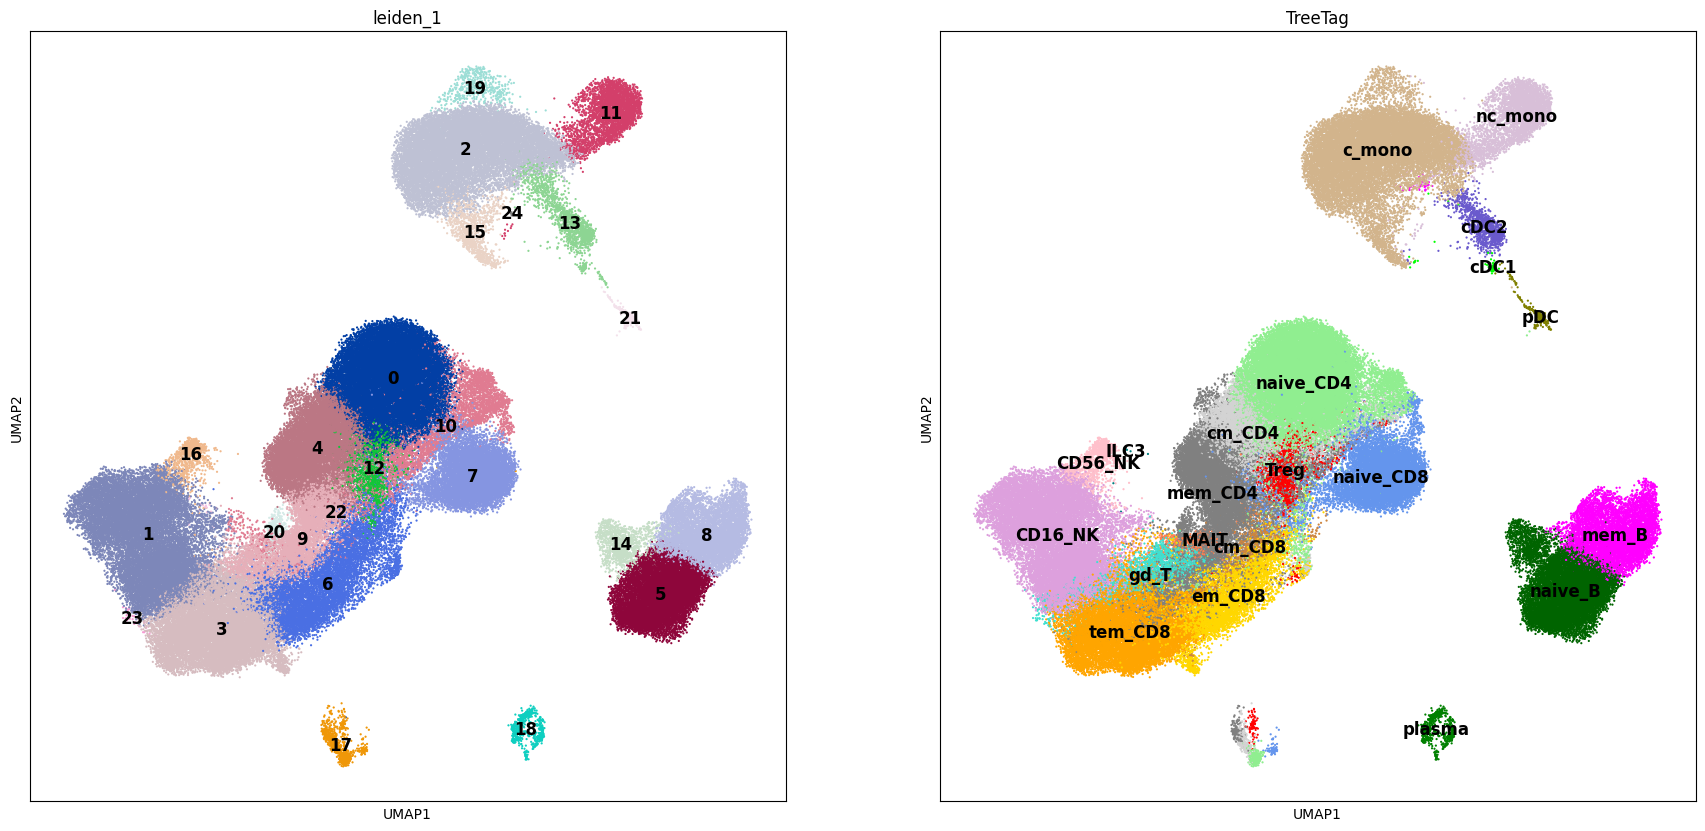

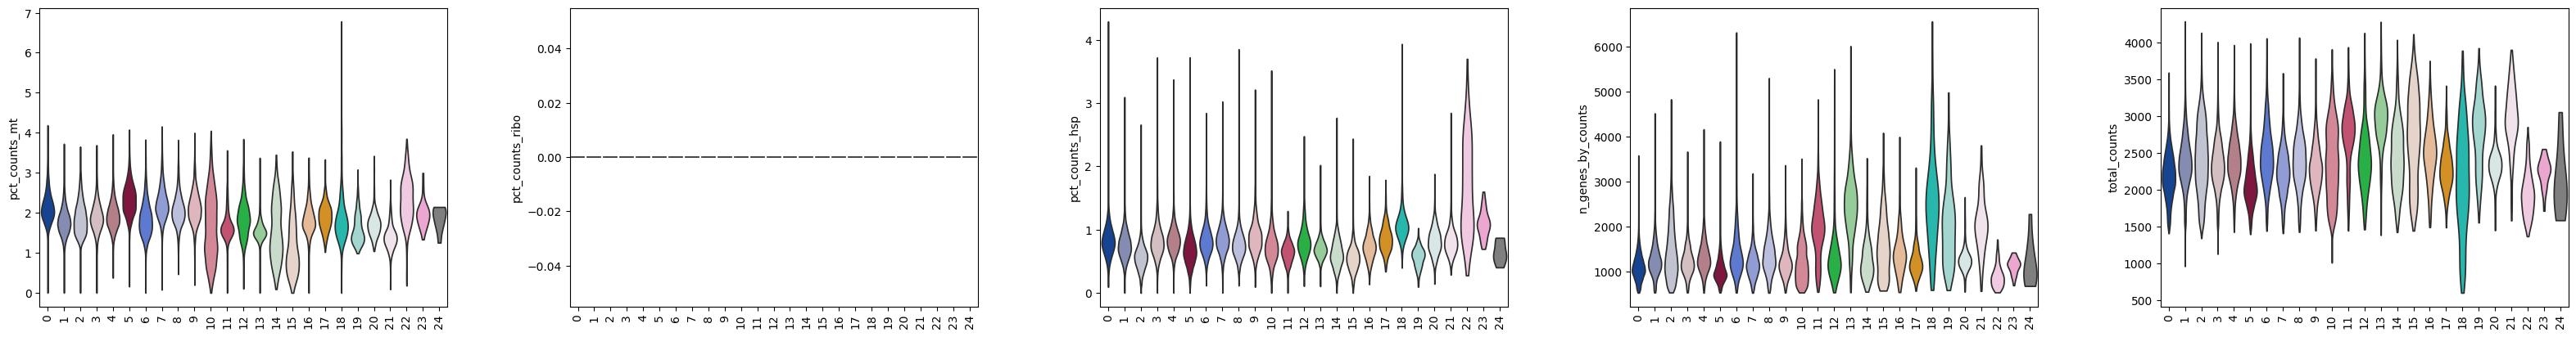

In [ ]:
  plt.rcParams['figure.figsize'] = (10, 10)
  sc.pl.umap(adata, color=['leiden_1','TreeTag'],legend_loc='on data', size=10,legend_fontsize=12)
  plt.rcParams['figure.figsize'] = (6, 5)
  sc.pl.violin(
      adata=adata,
      keys=['pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hsp', 'n_genes_by_counts', 'total_counts'],
      groupby='leiden_1', stripplot=False, jitter=False, rotation=90)

### Apply QC

In [ ]:
## filter non-cells
print ("Before: "); print (adata.shape)
sc.pp.filter_cells(adata, min_genes=300)
print ("After: "); print (adata.shape)


In [ ]:
# QC subset-------------------------------------------------

# Define QC filters
qc_pass = (
    (adata.obs['pct_counts_mt'] <= 2.75) &
    (adata.obs['pct_counts_ribo'] >= 7) &
    (adata.obs['pct_counts_hsp'] <= 1.5) &
    (adata.obs['n_genes_by_counts'] >= 800) &
    (adata.obs['total_counts'] >= 1500)
    )

# Before / After counts
total_before = adata.n_obs
total_after = qc_pass.sum()

# Counts per TreeTag category
before_counts = adata.obs['leiden_2'].value_counts().sort_index()
after_counts = (
    adata.obs.loc[qc_pass, 'leiden_2']
    .value_counts()
    .reindex(before_counts.index)
    .fillna(0)
    .astype(int))

# Create and print report
report = pd.DataFrame({
    'before': before_counts,
    'after': after_counts,
    'retained_%': (after_counts / before_counts * 100).round(2).astype(str) + '%'
})

print(f'Total cells before QC: {total_before:,}')
print(f'Total cells after QC: {total_after:,} ({total_after / total_before:.1%} retained)\n')
print(report)

# Confirm before subsetting
confirm = input('\nProceed with QC subset? (y/n): ')

if confirm.lower() == 'y':
    adata = adata[qc_pass].copy()
    print('\nQC filtering applied and data subsetted.')
else:
    print('\nQC filtering not applied. Data remains unchanged.')



## Tweaks

### adata

In [134]:
adata

AnnData object with n_obs × n_vars = 111324 × 2828
    obs: 'mapped_reference_annotation', 'library_uuid', 'assay_ontology_term_id', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'sample_preservation_method', 'sample_source', 'donor_BMI_at_collection', 'tissue_type', 'suspension_derivation_process', 'suspension_enriched_cell_types', 'suspension_type', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'donor_cause_of_death', 'donor_living_at_sample_collection', 'donor_smoking_status', 'disease_ontology_term_id', 'sex_ontology_term_id', 'cmv', 'Gross_annotation', 'tissue_ontology_term_id', 'sample_derivation_process', 'suspension_depletion_factors', 'suspension_depleted_cell_types', 'suspension_dissociation_reagent', 'suspension_dissociation_time', 'library_uuid_demultiplexed_tissue', 'age', 'development_stage_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'T_NK_score'

### Recompute clusters

In [ ]:
  # sc.pp.neighbors(adata, use_rep='X_pca_harmony'),
  # sc.tl.umap(adata)
  sc.tl.leiden(adata, resolution=2, key_added='leiden_2',flavor = 'igraph',n_iterations=1)

### Remove non-coding genes

In [ ]:
# Remove non-coding genes
gc.collect()
print (adata.shape)
# Ensure var_names are unique before calling coding_genes
adata.var_names_make_unique()
adata = coding_genes (adata)
print (adata.shape)

In [ ]:
# Load backed adata into memory
adata = adata.to_memory()
print(f"adata loaded into memory. Shape: {adata.shape}")

In [ ]:
# Rename gene
adata.var_names = adata.var_names.to_series().replace({"FOXP3_1": "FOXP3"})

### Delete cell categories

In [ ]:
  # adata = adata[~adata.obs['author_cell_type'].str.endswith('-Doublet')].copy()
  # adata = adata[adata.obs['leiden_1'].isin(['5'])].copy() # retain
  # adata = adata[~adata.obs['leiden_1'].isin(['11'])].copy() # remove
  adata = adata[~adata.obs['TreeTag'].isin(['plt'])].copy() # remove

### split into dictionary

In [ ]:
adata_full=adata
adata_dict = split(adata, category = 'TreeTag', min_cells=30)
adata = adata_dict ['T_NK']

### Check shape

In [ ]:
print(f"Shape of adata.X: {adata.X.shape}")
if adata.raw is None:
    print("adata.raw is None. Raw data is not available.")
else:
    print(f"Shape of adata.raw.X: {adata.raw.X.shape}")

Shape of adata.X: (59572, 33145)
adata.raw is None. Raw data is not available.


### Pull X from raw

In [ ]:
adata = restore_from_raw(adata)

✅ Full X and raw restored. shape = (136408, 23513), raw = (136408, 23513)


### Pull raw from X

In [ ]:
def has_nans(X):
    if sp.issparse(X):
        # Convert only the data (non-zero entries) to dense array for NaN check
        return np.isnan(X.data).any()
    else:
        return np.isnan(X).any()

if has_nans(adata.X):
    print("⚠️ Warning: adata.X contains NaNs. Don't set this as raw.")
else:
    adata.raw = adata.copy()
    print("✅ adata.raw set successfully.")

### Remove unused categories

In [ ]:
adata.obs['TreeTag'] = adata.obs['TreeTag'].cat.remove_unused_categories()

### Merge datasets

In [ ]:
def merge_ds(adata, adata):
    import pandas as pd

    adata.obs_names_make_unique()
    adata.obs_names_make_unique()

    adata.obs['dataset_origin'] = 'A'
    adata.obs['dataset_origin'] = 'H'

    adata.obs = adata.obs.rename(columns={
        'Sample_ID': 'sample',
        'COND': 'condition'
    })

    # Ensure existence and fill where missing (with categorical safety)
    if 'condition' not in adata.obs:
        adata.obs['condition'] = 'T1D'
    elif pd.api.types.is_categorical_dtype(adata.obs['condition']):
        adata.obs['condition'] = adata.obs['condition'].cat.add_categories(['T1D'])
        adata.obs['condition'] = adata.obs['condition'].fillna('T1D')
    else:
        adata.obs['condition'] = adata.obs['condition'].fillna('T1D')

    if 'treatment' not in adata.obs:
        adata.obs['treatment'] = 'untreated'
    elif pd.api.types.is_categorical_dtype(adata.obs['treatment']):
        adata.obs['treatment'] = adata.obs['treatment'].cat.add_categories(['untreated'])
        adata.obs['treatment'] = adata.obs['treatment'].fillna('untreated')
    else:
        adata.obs['treatment'] = adata.obs['treatment'].fillna('untreated')

    # Ensure both have all required obs columns
    for col in ['sample', 'treatment', 'condition']:
        if col not in adata.obs:
            adata.obs[col] = pd.NA
        if col not in adata.obs:
            adata.obs[col] = pd.NA

    # Outer join on genes
    adata = ad.concat(
        [adata, adata],
        axis=0,
        join='outer',
        merge='same',
        index_unique='-'
    )

    # Fill NaNs after concat
    for col, fill_val in [('condition', 'T1D'), ('treatment', 'untreated')]:
        if pd.api.types.is_categorical_dtype(adata.obs[col]):
            if fill_val not in adata.obs[col].cat.categories:
                adata.obs[col] = adata.obs[col].cat.add_categories([fill_val])
        adata.obs[col] = adata.obs[col].fillna(fill_val)

    # New group column
    adata.obs['group'] = (
        adata.obs['condition'].astype(str) + "_" + adata.obs['treatment'].astype(str)
    )

    return adata

adata = merge_ds(adata, adata)

## Annotation

### DGE

In [158]:

df = DGE(
    adata= adata,
    groupby='author_cell_type',
    target_group=['b_age'],
    reference_group='b_naive',
    min_log2fc=0.6,
    min_delta_pct = 0.6,
    min_pct = 0.6,
    n_sample=10000,
    n_genes=20,
    return_df=True,
    direction = "pos"
)
display (df.head(100))

,gene,mean_target,mean_ref,pct_target,pct_ref,delta_pct,log2fc,pval,pval_adj
9,CRIP1,1.81e+00,2.73e-01,9.26e-01,2.65e-01,6.61e-01,1.53e+00,3.59e-10,1.79e-09
4,DUSP2,1.40e+00,2.12e-01,1.00e+00,2.15e-01,7.85e-01,1.19e+00,5.56e-10,2.03e-09
8,SRGN,1.34e+00,2.81e-01,9.63e-01,2.82e-01,6.81e-01,1.06e+00,6.08e-10,2.03e-09
1,MCL1,1.33e+00,2.82e-01,1.00e+00,2.91e-01,7.09e-01,1.04e+00,2.19e-11,4.38e-10
14,COTL1,1.36e+00,3.31e-01,9.63e-01,3.33e-01,6.30e-01,1.03e+00,2.20e-08,4.00e-08
10,IGHG2,1.00e+00,2.19e-02,8.15e-01,2.38e-02,7.91e-01,9.78e-01,1.35e-07,1.93e-07
13,CIB1,1.28e+00,2.97e-01,9.63e-01,3.16e-01,6.47e-01,9.78e-01,1.67e-10,1.11e-09
18,ITGB2,1.08e+00,1.79e-01,9.63e-01,1.96e-01,7.67e-01,9.03e-01,4.50e-11,4.50e-10
0,FGR,8.37e-01,4.07e-02,8.89e-01,4.68e-02,8.42e-01,7.96e-01,7.02e-09,1.66e-08
15,ADGRE5,9.84e-01,1.93e-01,8.89e-01,1.97e-01,6.92e-01,7.90e-01,8.29e-07,9.75e-07


#### DotPlot and UMAPs

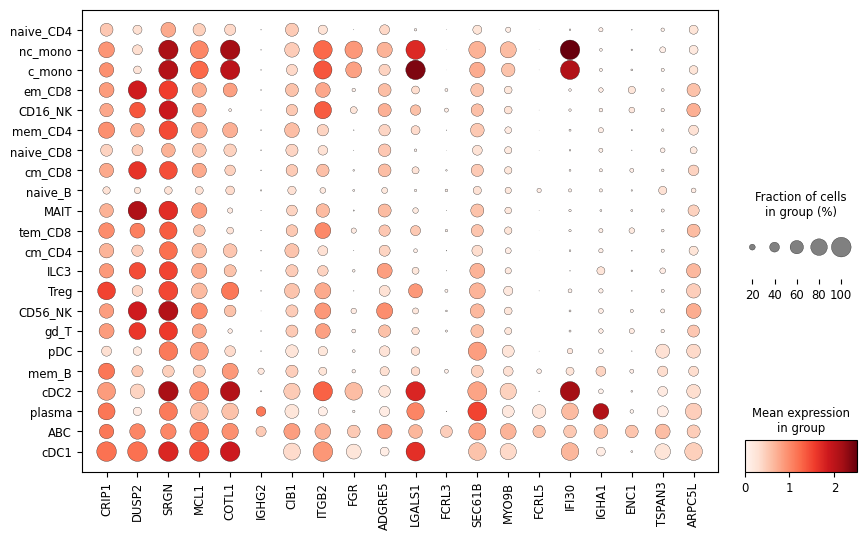

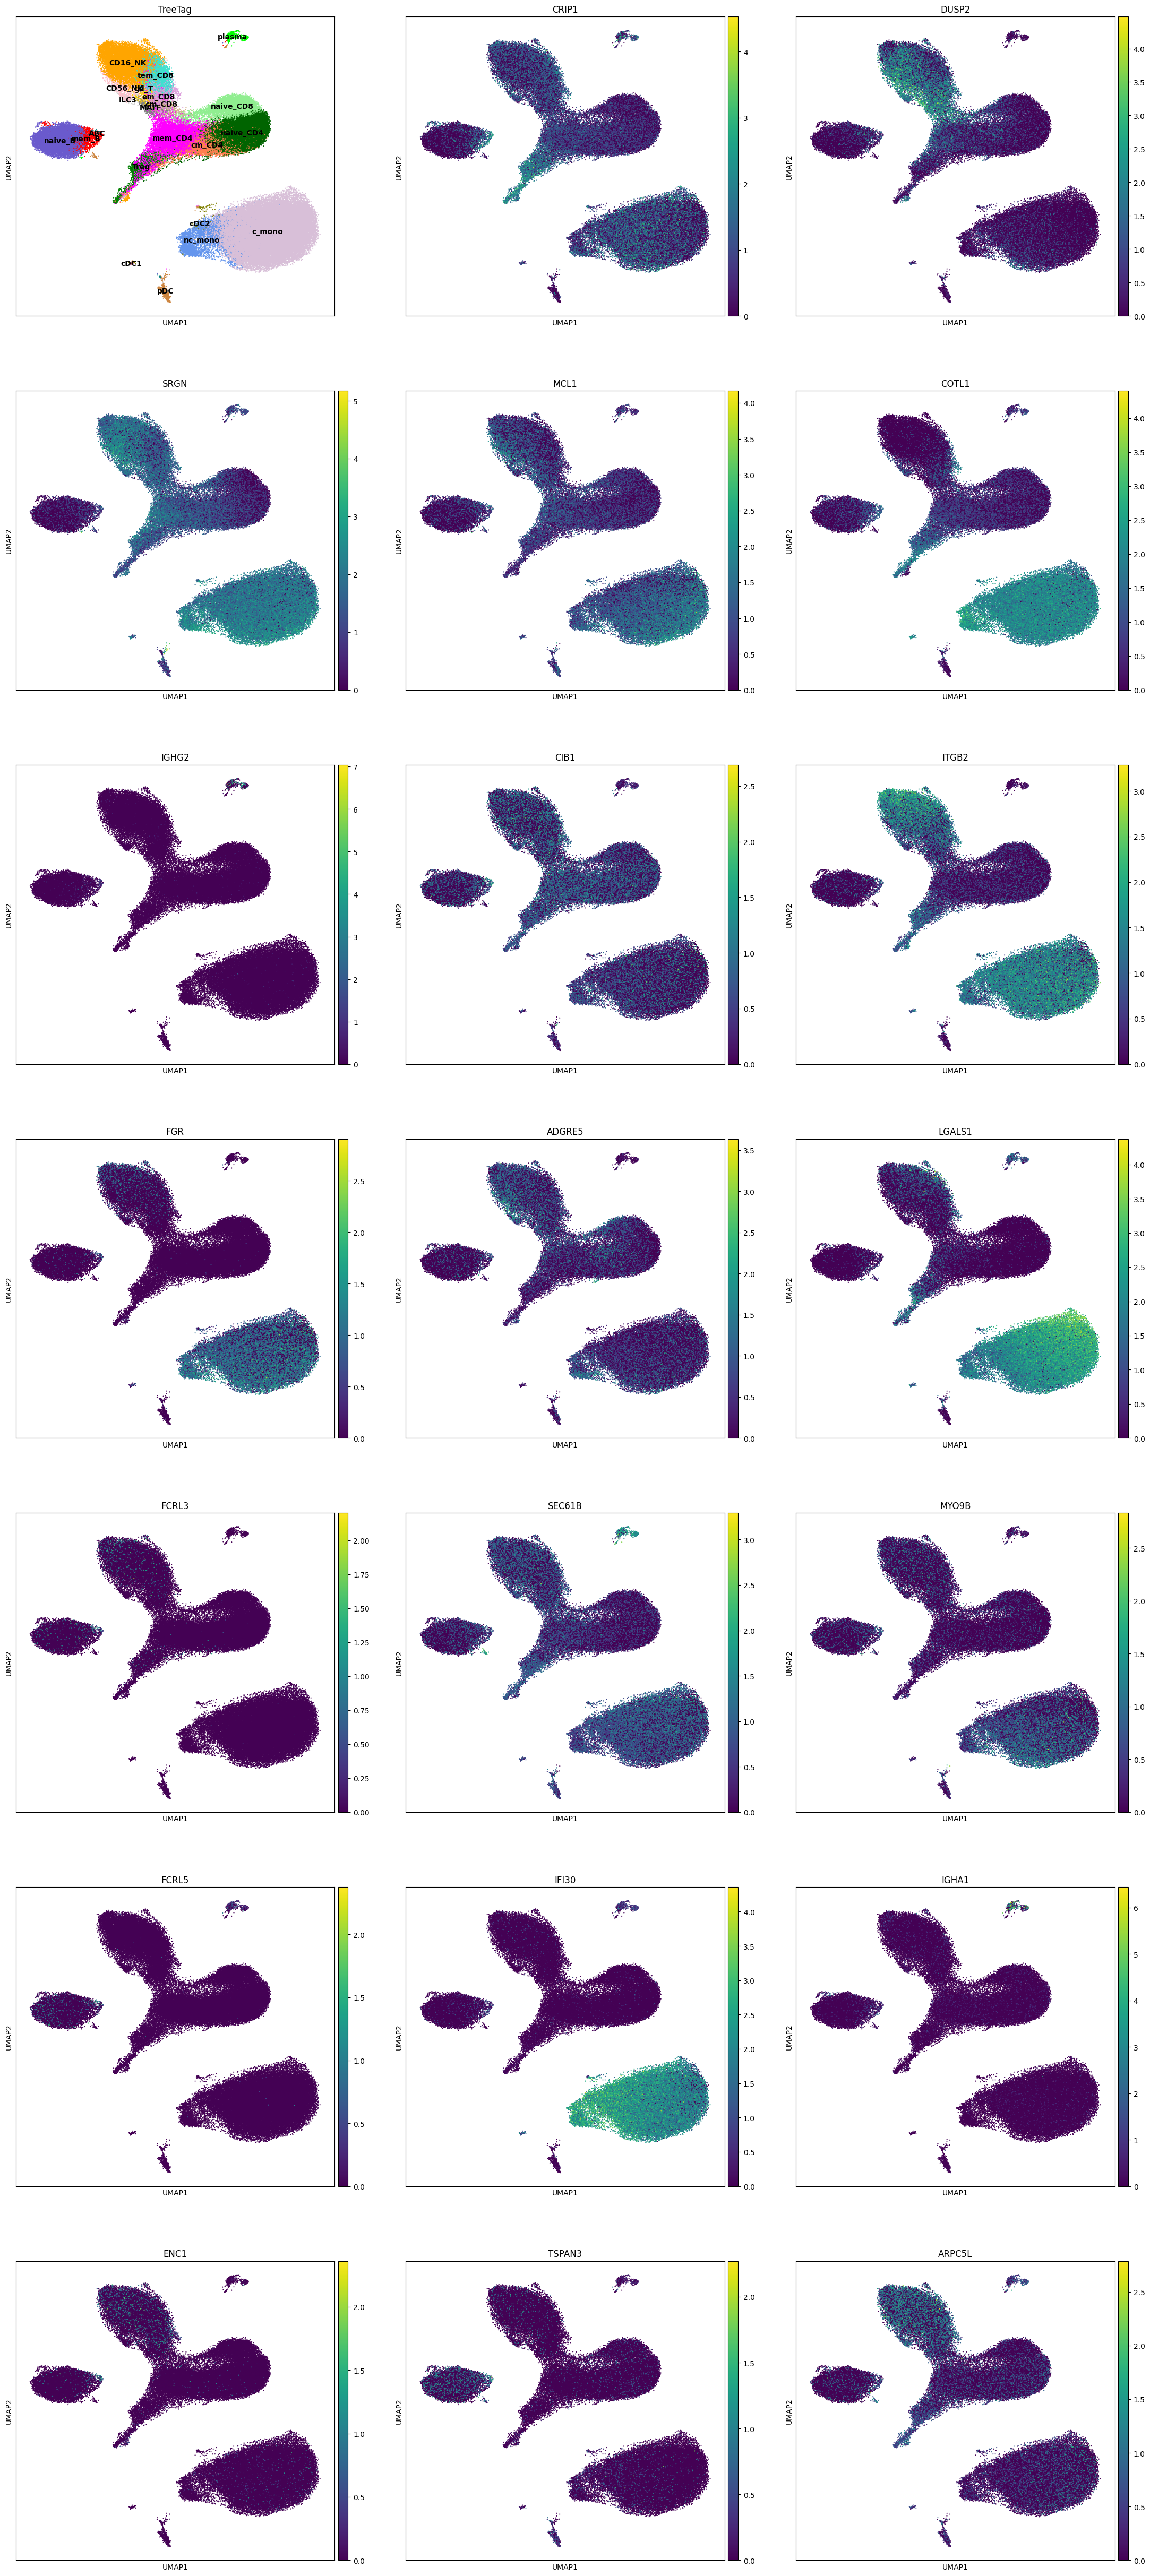

In [160]:

genes = list (df.head(25)['gene'])
# genes = markers ('CD16_NK',adata=adata, sign = 'pos')
sc.pl.dotplot(adata,var_names=genes,groupby='TreeTag', standard_scale=None, figsize=(10, 6), cmap='Reds')
sc.pl.umap(
  adata=adata,
  color= ['TreeTag'] + genes,
  palette = set4,
  cmap='viridis',
  use_raw = True,
  sort_order = False,
  legend_loc='on data', legend_fontsize=10, legend_fontweight='bold',
  ncols=3, size=10, alpha=1,
  vmax= None,
  na_color='gray' # Explicitly set the missing value color
  )

In [161]:
print (genes)

['CRIP1', 'DUSP2', 'SRGN', 'MCL1', 'COTL1', 'IGHG2', 'CIB1', 'ITGB2', 'FGR', 'ADGRE5', 'LGALS1', 'FCRL3', 'SEC61B', 'MYO9B', 'FCRL5', 'IFI30', 'IGHA1', 'ENC1', 'TSPAN3', 'ARPC5L']



#### Enrichment

In [162]:
genes = df['gene']
results = enrich (genes, type = 'cell_state')
top50 = results.head(50)
display(top50)



,Library,Term,PValue,AdjustedPValue,OverlappingGenes
0,Reactome_Pathways_2024,Immune System,1.05e-04,7.31e-03,"FGR, IGHG2, ADGRE5, ITGB2, COTL1, MYO9B, SEC61..."
5,Reactome_Pathways_2024,Innate Immune System,6.85e-04,9.13e-03,"FGR, IGHG2, ADGRE5, ITGB2, COTL1, MYO9B"


#### ChatGPT query

In [163]:

display (ChatGPT (genes, 'TILs', 'follicular lymphoma'))

NameError: name 'openai_client' is not defined

In [ ]:
# prompt: form a new column called "treatment" which is equal "IL2" when timepoint is "D7" or 'D42' and equal 'none' when not

adata.obs['treatment'] = adata.obs['timepoint'].apply(lambda x: 'treated' if x in ['d7', 'd42'] else 'untreated')


### Cell counts

In [ ]:
# Count cells per TreeTag
cell_counts_table = adata.obs['author_cell_type'].value_counts().reset_index()
cell_counts_table.columns = ['author_cell_type', 'Cell Count']

# Display as a nice table
display(cell_counts_table)


### confusion matrix

In [ ]:
# counts or percentages — both work; counts give the most sensible matching
cm = pd.crosstab(adata_old.obs['TreeTag'], adata.obs['author_cell_type'])
cm_re, row_order, col_order = diagonalize (cm)

# If you want row-normalized % after reordering:
cm_pct = (cm_re.div(cm_re.sum(axis=1).replace(0, np.nan), axis=0) * 100).fillna(0.0)
plt.rcParams['figure.figsize'] = (10, 8)
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Reds', annot_kws={"size": 7},
            square=(cm_pct.shape[0] == cm_pct.shape[1]))
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()


In [ ]:
gc.collect()

In [ ]:
adata





### Run pipeline

In [118]:
if adata.raw is None:
  adata.raw = adata.copy()
if (adata.raw.X.shape != adata.X.shape):
  adata = restore_from_raw(adata)
# sc.pp.normalize_total(adata=adata, target_sum=1e4)
# sc.pp.log1p(adata)
adata = convert (adata_old)
# adata = coding_genes (adata)
# adata.obs_names_make_unique()
adata = pipeline (adata, harmony=True, sample_key = 'donor_id',  n_top_genes=3000, downsample_n = 2000 )

✅ Using symbols from adata.var['feature_name']; renamed 0 genes.
🔄 Starting pipeline…
✅ Using symbols from adata.var['feature_name']; renamed 0 genes.
📉 Step 1: Downsampling to 2000 cells…
🧹 Step 2: Filtering zero‐sum genes…
   → 36406 → 29534 genes kept.
⏭️ Step 3: Skipping alias conversion.
Step 4: Normalizing & log1p…
   - full already transformed
   - subset already transformed
💾 Step 4b: Cached normalized+log1p data in adata.raw.
✨ Step 5: Selecting HVGs…
   → Excluding BCR/TCR; 2828 HVGs remain.


/usr/local/lib/python3.12/dist-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


🧮 Step 6: Scaling + PCA…


/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


   → PCA on subset complete.


/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
2025-08-27 12:13:42,659 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
INFO:harmonypy:Computing initial centroids with sklearn.KMeans...


   → Projected full dataset into PCA space.
🔀 Step 7: Running Harmony on 'donor_id'…


2025-08-27 12:13:53,765 - harmonypy - INFO - sklearn.KMeans initialization complete.
INFO:harmonypy:sklearn.KMeans initialization complete.
2025-08-27 12:13:54,309 - harmonypy - INFO - Iteration 1 of 10
INFO:harmonypy:Iteration 1 of 10
2025-08-27 12:14:43,032 - harmonypy - INFO - Iteration 2 of 10
INFO:harmonypy:Iteration 2 of 10
2025-08-27 12:15:29,780 - harmonypy - INFO - Iteration 3 of 10
INFO:harmonypy:Iteration 3 of 10
2025-08-27 12:16:16,042 - harmonypy - INFO - Iteration 4 of 10
INFO:harmonypy:Iteration 4 of 10
2025-08-27 12:17:02,418 - harmonypy - INFO - Converged after 4 iterations
INFO:harmonypy:Converged after 4 iterations


   → Harmony integration complete.
🧭 Step 8: Neighbors calculated.
🗺️ Step 9: UMAP computed.
🧬 Step 10: Leiden clustering complete.
♻️ Step 11: Restored adata.raw.
🧼 Step 12: Sanitizing sparse matrix…
✅ Pipeline complete.


### Run TreeTag

[TreeTag] pruning_min_fc=1.25 → ON
[Prune] T_NK: kept 8/8 (+markers, FC vs avg(others) ≥ 1.25).
[Prune] B: kept 5/5 (+markers, FC vs avg(others) ≥ 1.25).
[Prune] myelo: kept 12/12 (+markers, FC vs avg(others) ≥ 1.25).
[TreeTag] split @ 'root' (cells=111324, X_used=111324x26, score=0.29s, children_scored=3)
[Prune] T: kept 5/5 (+markers, FC vs avg(others) ≥ 1.25).
[Prune] ILC: kept 13/13 (+markers, FC vs avg(others) ≥ 1.25).
[TreeTag] split @ 'T_NK' (cells=59034, X_used=59034x18, score=0.16s, children_scored=2)
[Prune] ILT: kept 4/4 (+markers, FC vs avg(others) ≥ 1.25).
[Prune] CD4: kept 6/6 (+markers, FC vs avg(others) ≥ 1.25).
[Prune] CD8: kept 2/2 (+markers, FC vs avg(others) ≥ 1.25).
[TreeTag] split @ 'T' (cells=47175, X_used=47175x14, score=0.14s, children_scored=3)
[Prune] MAIT: kept 12/12 (+markers, FC vs avg(others) ≥ 1.25).
[Prune] gd_T: kept 6/6 (+markers, FC vs avg(others) ≥ 1.25).
[TreeTag] split @ 'ILT' (cells=1615, X_used=1615x19, score=0.02s, children_scored=2)
[Prune] LN

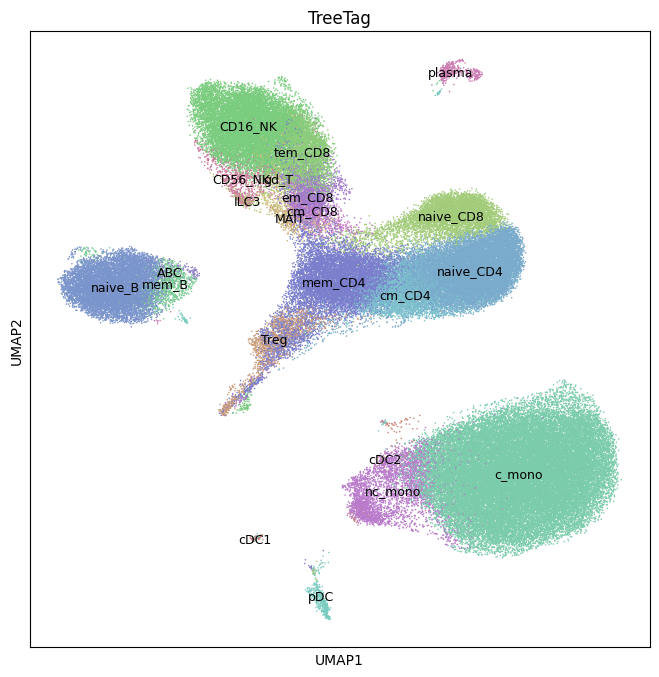

In [166]:
TreeTag (adata=adata, tree_yaml='PBMC.yaml', # 'coarse.yaml','tree_TIL.yaml','tree.yaml'
                markers_yaml='PBMC_markers.yaml', smoothing = True, verbose = True,
                majority_vote=True, root = 'root', min_score = 0,
                save_scores= True, min_pruning_fc=1.25)
plt.rcParams['figure.figsize'] = (8, 8)
G = init_tree('PBMC.yaml', 'PBMC_markers.yaml', root='root',adata=adata)

sc.pl.umap(
  adata=adata,
  color=  'TreeTag',
  # palette = "Set3", alpha=1,
  palette  = palette_from_graph(G, root="root", saturation=0.4, brightness=0.8, order= "random"),
  legend_loc='on data', legend_fontsize=9, legend_fontweight='regular',
  use_raw = True, size = 5, ncols= 3)

### Find doublets

In [149]:
find_doublets (adata=adata, root="root", tree_yaml="PBMC.yaml", markers_yaml= "PBMC_markers.yaml")

{'n_cells': 111324, 'families': ['T_NK', 'B', 'myelo'], 'root': 'root'}

## visualizations

### UMAP

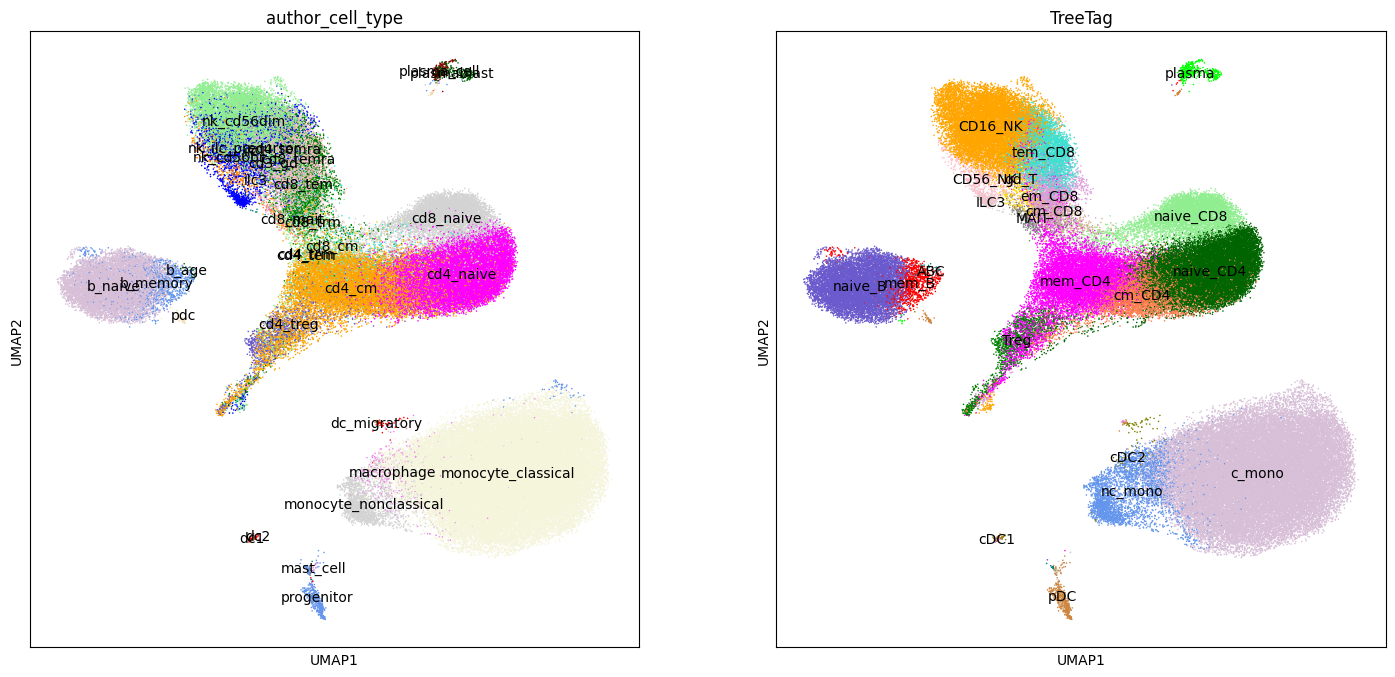

In [154]:
plt.rcParams['figure.figsize'] = (8, 8)
sc.pl.umap(
    adata,
    # color= markers ('ABC',adata=adata, markers_yaml='PBMC_markers.yaml', tree_yaml='PBMC.yaml'),
    color=['author_cell_type','TreeTag'],
    # color = subscores (root_cell='root',adata=adata,markers_yaml='PBMC_markers.yaml',tree_yaml='PBMC.yaml', only_leaves=False),
    # color = ['TreeTag'] + markers ('ILC3', markers_yaml='PBMC_markers.yaml', tree_yaml='PBMC.yaml'),
    # color = ['doublet_score','doublet_partner'],
    # color = ['ABC_score'],
    palette=set4,
    cmap='viridis',
    # palette  = palette_from_graph(G, root="leukocyte", saturation=0.4, brightness=0.8, order= 'random'),
    size=5,
    alpha=None,       # transparency off = faster
    show=True,
    legend_loc='on data',
    legend_fontweight = 'regular',
    ncols=4
)


### Plot tree

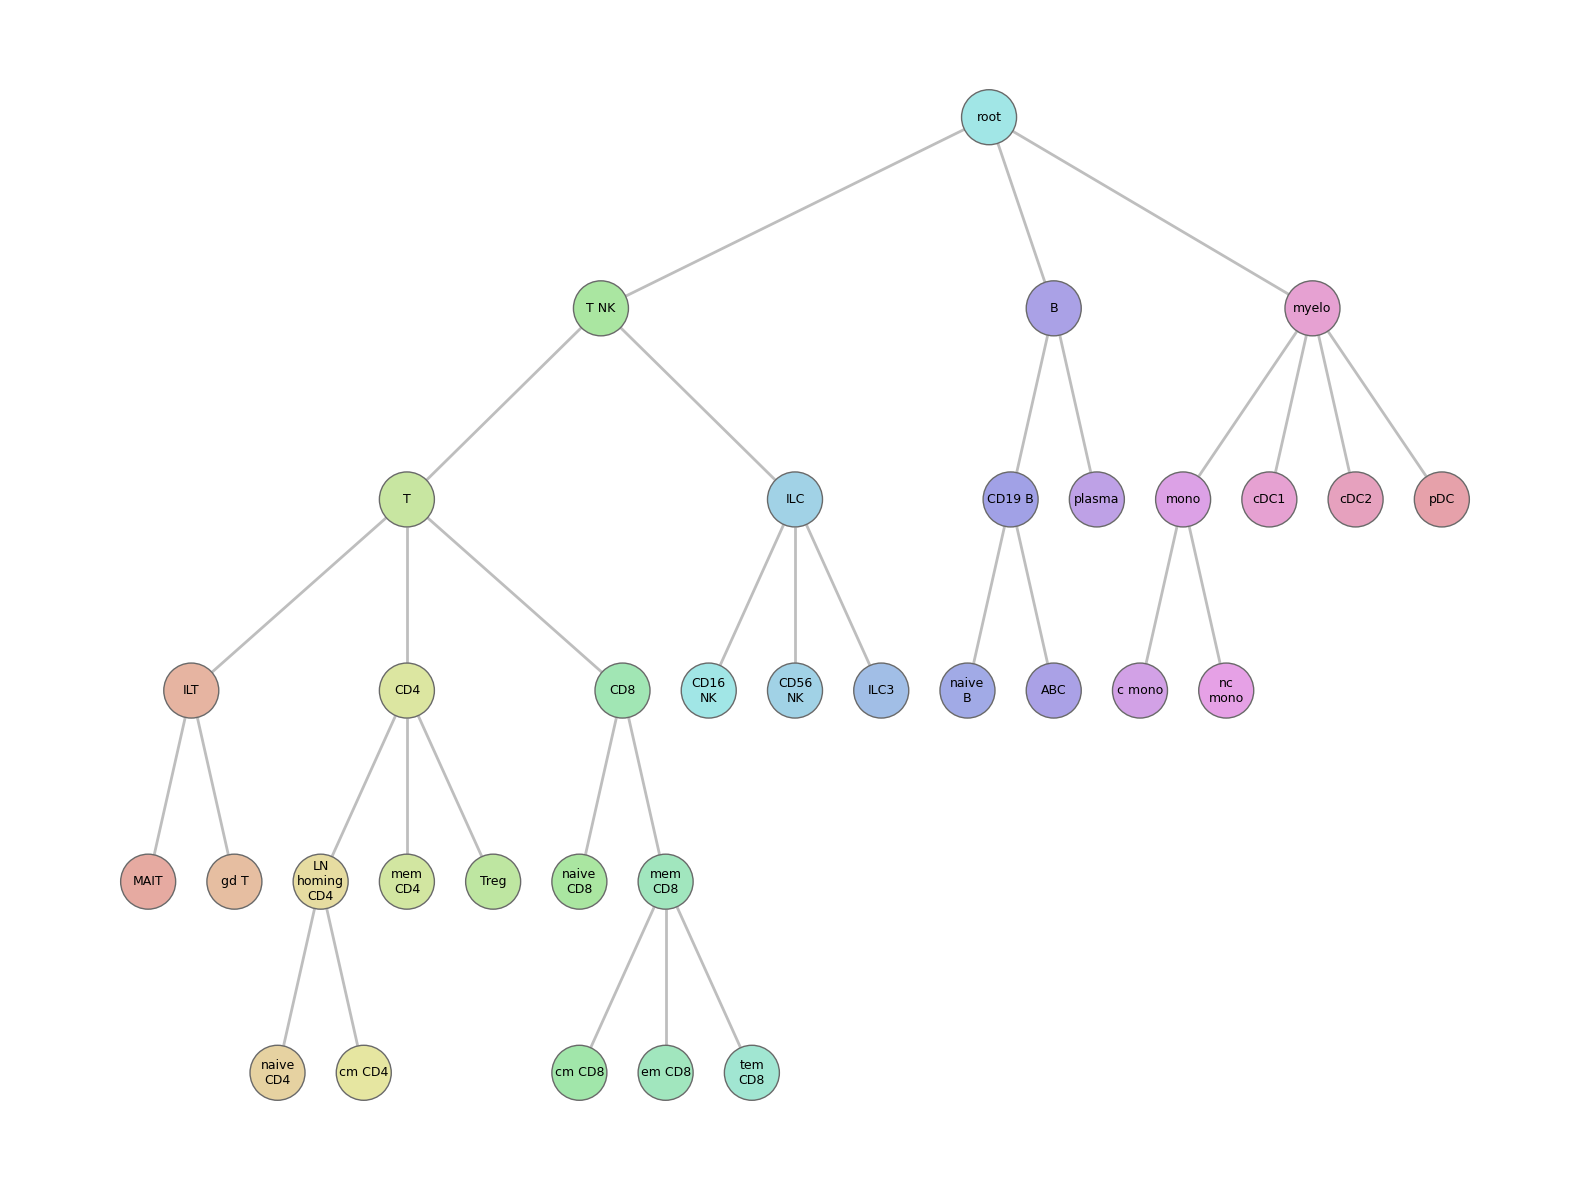

In [136]:
G = init_tree('PBMC.yaml', 'PBMC_markers.yaml', root='root',adata=adata)
palette = palette_from_graph(G, root="root", saturation=0.3, brightness=0.9, order = 'ID')
plot_tree(G, root='root', vertex_size=55, vertex_label_size=9, bbox=(1600,1200), palette=palette)

### Dot Plot

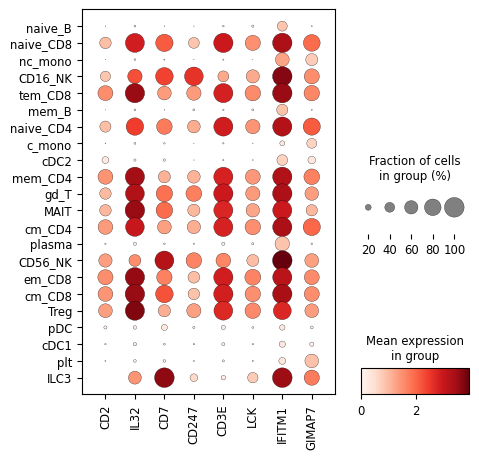

In [ ]:
# Dot Plot
genes = markers ('T_NK')
# Convert 'week' to string to avoid potential interval issues in dotplot
# adata.obs['week_str'] = adata.obs['week'].astype(str)

sc.pl.dotplot(adata, vmax= None,
              var_names=genes,
              groupby='TreeTag', # Use the new string column for grouping
              standard_scale=None,  dendrogram=False, use_raw=True, figsize=(5, 5))

### Remove doublets

In [ ]:
x_name = "B_score"
y_name = "T_NK_score"
x = adata.obs[x_name]
y = adata.obs[y_name]
c = adata.obs["n_genes_by_counts"]

plt.figure(figsize=(6,6))
plt.scatter(x, y, c=c, s=1, alpha=1) # Removed 'sc =' from this line
plt.colorbar(label="n_genes_by_counts") # Removed 'sc' from this line
plt.axvline(0.1, ls="--", lw=1)  # threshold line
plt.axhline(0.1, ls="--", lw=1)
plt.xlabel(xlabel=x_name)
plt.ylabel(y_name)
plt.xlim(0,1)
plt.ylim(0,1)
plt.gca().set_aspect("equal", "box")
plt.tight_layout()
plt.show()

if False:
  adata = adata[~((adata.obs[x_name] > 0.1) & (adata.obs[y_name] > 0.1))].copy()

### Movie frames

In [ ]:
def _leaf_counts(G, r):
    cnt = [0]*G.vcount()
    def dfs(u):
        kids = G.successors(u)
        if not kids: cnt[u] = 1
        else:        cnt[u] = sum(dfs(k) for k in kids)
        return cnt[u]
    dfs(r); return cnt

def compute_intervals(G, root, order="size"):
    """Final tree → {vid: (h0,h1)} intervals; stable across all frames."""
    r = G.vs.find(name=root).index
    cnt = _leaf_counts(G, r)
    intervals = {}
    def assign(u, h0, h1):
        intervals[u] = (h0, h1)
        kids = G.successors(u)
        if not kids: return
        if order == "size":
            kids = sorted(kids, key=lambda k: (-cnt[k], G.vs[k]["name"]))
        else:
            kids = sorted(kids, key=lambda k: G.vs[k]["name"])
        tot = sum(cnt[k] for k in kids) or len(kids)
        cur = h0
        for k in kids:
            frac = (cnt[k]/tot) if tot else 1/len(kids)
            nxt = cur + (h1-h0)*frac
            assign(k, cur, nxt); cur = nxt
    assign(r, 0.0, 1.0)
    return intervals

def visible_nodes_for_stage(G, root, expanded:set[str]):
    """
    ‘expanded’ = node names you chose to split open in this frame.
    Returns the frontier nodes to draw (coarse partition).
    """
    r = G.vs.find(name=root).index
    vis = []
    def walk(u):
        name = G.vs[u]["name"]
        kids = G.successors(u)
        if not kids or name in expanded:
            for k in kids: walk(k)   # expanded → show children
        else:
            vis.append(u)            # not expanded → keep as one node
    walk(r)
    return vis

def hsv_hex(h, s, v):
    r,g,b = colorsys.hsv_to_rgb(h%1.0, max(0,min(1,s)), max(0,min(1,v)))
    return "#{:02X}{:02X}{:02X}".format(int(round(r*255)), int(round(g*255)), int(round(b*255)))




In [ ]:
def TreeTag_frames(
    adata,
    tree_yaml: str,
    markers_yaml: str,
    root: str,
    frames_dir: str = "treetag_frames",
    size: float = 4.0,
    legend_fontsize: float = 9,
    legend_fontweight: str = "regular",
    palette: str | dict | list = "random",
    smoothing: bool = True,
    pre_scale: bool = True,
    verbose: bool = True,
    annot_xy: tuple[float, float] = (0.03, 0.97),
    majority_vote: bool = False,
    save_scores: bool = False,
):
    """Progressive TreeTag with per-split frames and stable graph-based colors."""
    import os, time, re
    import numpy as np
    import pandas as pd
    import scanpy as sc
    from hashlib import blake2b
    from scipy.sparse import csc_matrix, csr_matrix, coo_matrix, dia_matrix, issparse

    def _safe_tag(s: str) -> str:
        return re.sub(r"[^A-Za-z0-9_.-]+", "_", s)

    def _palette_for_cats(cats, color_palette):
        if color_palette is None:
            return None
        if isinstance(color_palette, dict):
            return [color_palette.get(c, "#808080") for c in cats]
        return list(color_palette)

    t0_all = time.perf_counter()
    os.makedirs(frames_dir, exist_ok=True)

    # 1) tree + markers
    G = init_tree(tree_yaml, markers_yaml, root=root)  # provided by caller
    use_raw = adata.raw is not None
    var_names = (adata.raw.var_names if use_raw else adata.var_names)
    valid = set(var_names)

    def _norm(md):
        out = {}
        for node, val in md.items():
            if isinstance(val, dict):
                pos = [g for g in val.get("pos", []) if g in valid]
                neg = [g for g in val.get("neg", []) if g in valid]
            else:
                pos = [g for g in val if not str(g).startswith("-") and g in valid]
                neg = [str(g)[1:] for g in val if str(g).startswith("-") and str(g)[1:] in valid]
            out[node] = {"pos": pos, "neg": neg}
        return out

    markers = _norm(marker_dict)
    ont_nodes = set(G.vs["name"])
    markers = {n: m for n, m in markers.items() if n in ont_nodes}

    # 2) Marker CSC cache (float32)
    marker_union = sorted({g for m in markers.values() for g in (m["pos"] + m["neg"])})

    def _hash_names(names):
        h = blake2b(digest_size=16)
        for s in names:
            h.update(str(s).encode("utf-8")); h.update(b"\0")
        return h.hexdigest()

    cache = adata.uns.get("_treetag_cache", {})
    want_meta = {
        "n_obs": int(adata.n_obs),
        "use_raw": bool(use_raw),
        "union_hash": _hash_names(marker_union),
        "version": 1,
        "dtype": "float32",
        "format": "csc",
    }
    X_csc = cache.get("X_csc")
    have = cache.get("meta")
    if not (have == want_meta and X_csc is not None and issparse(X_csc)
            and getattr(X_csc, "format", "") == "csc"
            and X_csc.dtype == np.float32
            and X_csc.shape == (adata.n_obs, len(marker_union))):
        col_map = {g: i for i, g in enumerate(var_names)}
        cols = [col_map[g] for g in marker_union]
        Xsrc = (adata.raw.X if use_raw else adata.X)
        X_mark = Xsrc[:, cols]
        X_csc = X_mark if (issparse(X_mark) and X_mark.format == "csc") else csc_matrix(X_mark)
        if X_csc.dtype != np.float32:
            X_csc = X_csc.astype(np.float32)
        adata.uns["_treetag_cache"] = {"X_csc": X_csc, "meta": want_meta}
        if verbose:
            print(f"[TreeTag_frames] prepared marker CSC in {time.perf_counter()-t0_all:.2f}s "
                  f"(cells={X_csc.shape[0]}, genes={X_csc.shape[1]})")
    g2col = {g: i for i, g in enumerate(marker_union)}

    # 3) Optional per-marker scaling by nonzero max
    scale_vec = None
    if pre_scale and len(marker_union):
        cache = adata.uns.setdefault("_treetag_cache", {})
        smeta = cache.get("scale_meta_max", {})
        want = {
            "n_obs": int(adata.n_obs), "use_raw": bool(use_raw),
            "union_hash": _hash_names(marker_union), "version": 1, "mode": "max_nonzero"
        }
        if smeta == want and "scale_vec_max" in cache and len(cache["scale_vec_max"]) == len(marker_union):
            scale_vec = cache["scale_vec_max"]
            if verbose:
                print("[TreeTag_frames] using cached pre-scale vector")
        else:
            indptr, data = X_csc.indptr, X_csc.data
            m = X_csc.shape[1]
            scale = np.ones(m, dtype=np.float32)
            for j in range(m):
                a = data[indptr[j]:indptr[j+1]]
                if a.size:
                    mx = a.max()
                    if mx > 1e-12:
                        scale[j] = np.float32(1.0/float(mx))
            scale_vec = scale
            cache["scale_vec_max"] = scale_vec
            cache["scale_meta_max"] = want
            adata.uns["_treetag_cache"] = cache

    # 4) Connectivities (row-normalized) for optional smoothing
    C_full = None
    if smoothing:
        conn_key = adata.uns.get("neighbors", {}).get("connectivities_key")
        if conn_key and conn_key in adata.obsp:
            C_full = adata.obsp[conn_key]
        elif "connectivities" in adata.obsp:
            C_full = adata.obsp["connectivities"]
        if C_full is not None and C_full.shape[0] == adata.n_obs:
            C_full = csr_matrix(C_full)
            rs = np.array(C_full.sum(axis=1)).ravel()
            rs[rs == 0] = 1.0
            C_full = C_full.multiply((1.0/rs)[:, None]).tocsr()
        else:
            C_full = None
            if verbose:
                print("[TreeTag_frames] no usable connectivities → smoothing off")

    def _children(node_name):
        return [G.vs[i]["name"] for i in G.successors(G.vs.find(name=node_name)) if i is not None]

    # Per-node weight cache
    node_cache = {}
    def _prepare_node(node, kids):
        if node in node_cache:
            return node_cache[node]
        used_cols, seen = [], set()
        child_list, pos_lists, neg_lists = [], [], []
        for c in kids:
            pidx = [g2col[g] for g in markers.get(c, {}).get("pos", []) if g in g2col]
            nidx = [g2col[g] for g in markers.get(c, {}).get("neg", []) if g in g2col]
            if not pidx:
                continue
            child_list.append(c); pos_lists.append(pidx); neg_lists.append(nidx)
            for gidx in pidx + nidx:
                if gidx not in seen:
                    seen.add(gidx); used_cols.append(gidx)
        if not child_list:
            node_cache[node] = dict(used_cols=[], child_list=[], W_pos=None, W_neg=None)
            return node_cache[node]
        local = {g: i for i, g in enumerate(used_cols)}
        data_p, rows_p, cols_p = [], [], []
        data_n, rows_n, cols_n = [], [], []
        for j, (pidx, nidx) in enumerate(zip(pos_lists, neg_lists)):
            if pidx:
                w = 1.0/float(len(pidx))
                rows_p.extend(local[g] for g in pidx); cols_p.extend([j]*len(pidx)); data_p.extend([w]*len(pidx))
            if nidx:
                w = 1.0/float(len(nidx))
                rows_n.extend(local[g] for g in nidx); cols_n.extend([j]*len(nidx)); data_n.extend([w]*len(nidx))
        n_local = len(used_cols)
        W_pos = coo_matrix((data_p, (rows_p, cols_p)), shape=(n_local, len(child_list))).tocsr()
        W_neg = coo_matrix((data_n, (rows_n, cols_n)), shape=(n_local, len(child_list))).tocsr() if data_n else None
        if pre_scale and scale_vec is not None and used_cols:
            scl = np.asarray(scale_vec, dtype=np.float32)[used_cols]
            D = dia_matrix((scl, 0), shape=(n_local, n_local)).tocsr()
            W_pos = D @ W_pos
            if W_neg is not None:
                W_neg = D @ W_neg
        node_cache[node] = dict(used_cols=used_cols, child_list=child_list, W_pos=W_pos, W_neg=W_neg)
        return node_cache[node]

    def _score_children_rows(row_idx, node, kids):
        c = _prepare_node(node, kids)
        used_cols, child_list, W_pos, W_neg = c["used_cols"], c["child_list"], c["W_pos"], c["W_neg"]
        if not child_list:
            return [], np.zeros((row_idx.size, 0), dtype=np.float32), 0
        X_used = X_csc[:, used_cols][row_idx, :].tocsr()
        P = X_used @ W_pos
        N = (X_used @ W_neg) if W_neg is not None else 0
        P = P.toarray() if hasattr(P, "toarray") else np.asarray(P)
        if hasattr(N, "toarray"): N = N.toarray()
        elif isinstance(N, int): pass
        else: N = np.asarray(N)
        Diff = P if isinstance(N, int) else (P - N)
        np.clip(Diff, 0, None, out=Diff)
        q1, q99 = np.quantile(Diff, 0.01, axis=0), np.quantile(Diff, 0.99, axis=0)
        S = (Diff - q1) / (q99 - q1 + 1e-9)
        np.clip(S, 0, 1, out=S)
        S = S.astype(np.float32, copy=False)
        if smoothing and C_full is not None and S.shape[1] > 0:
            C_sub = C_full[row_idx, :][:, row_idx].tocsr()
            C_sub.setdiag(0.0)
            rs = np.array(C_sub.sum(axis=1)).ravel(); rs[rs == 0] = 1.0
            C_sub = C_sub.multiply((1.0/rs)[:, None]).tocsr()
            S = C_sub @ S
        return child_list, S, len(used_cols)

    # Palette (single computation)
    color_palette = None
    try:
        if palette == "random":
            color_palette = palette_from_graph(G, root=root, saturation=0.4, brightness=0.8, order="random")
        elif isinstance(palette, (dict, list, tuple)):
            color_palette = palette
        elif palette in (None, "scanpy", "default"):
            color_palette = None
        else:
            raise ValueError(f"Unsupported palette spec: {palette!r}")
    except Exception as e:
        print(f"Warning: graph palette failed ({e}). Falling back to Scanpy defaults.")
        color_palette = None

    # 5) Progressive traversal + frames
    labels = np.array([root]*adata.n_obs, dtype=object)
    frame_id = 0
    algo_time_cum = 0.0

    def _save_frame(tag_text, t_compute_cum):
        adata.obs["TreeTag_frame"] = pd.Categorical(labels)
        adata.obs["TreeTag_frame"] = adata.obs["TreeTag_frame"].cat.remove_unused_categories()
        cats = list(adata.obs["TreeTag_frame"].cat.categories)
        pal_list = _palette_for_cats(cats, color_palette)
        fig = sc.pl.umap(
            adata, color="TreeTag_frame",
            palette=pal_list,
            legend_loc="on data", legend_fontsize=legend_fontsize, legend_fontweight=legend_fontweight,
            size=size, frameon=False, use_raw=False, title="", show=False, return_fig=True
        )
        fig.text(annot_xy[0], annot_xy[1], f"{tag_text}\n{t_compute_cum:.2f} s",
                 ha="left", va="top", fontsize=13)
        path = os.path.join(frames_dir, f"{frame_id:03d}_{_safe_tag(tag_text)}.png")
        fig.savefig(path, dpi=200, bbox_inches="tight")
        return path

    def _walk(node, row_idx):
        nonlocal frame_id, algo_time_cum, labels
        kids = [k for k in _children(node) if k in markers]
        if not kids or row_idx.size == 0:
            labels[row_idx] = node
            return
        t_compute_start = time.perf_counter()
        child_names, S, n_local = _score_children_rows(row_idx, node, kids)
        if S.shape[1] == 0:
            labels[row_idx] = node
            return
        best = S.argmax(axis=1)
        for j, child in enumerate(child_names):
            m = (best == j)
            if m.any():
                labels[row_idx[m]] = child
        algo_time_cum += (time.perf_counter() - t_compute_start)
        frame_id += 1
        out_path = _save_frame(f"split@{node}", algo_time_cum)
        if verbose:
            print(f"[TreeTag_frames] split @{node}: cells={row_idx.size}, X_used={row_idx.size}x{n_local} → {out_path}")
        for j, child in enumerate(child_names):
            m = (best == j)
            if m.any():
                _walk(child, row_idx[m])

    _walk(root, np.arange(adata.n_obs, dtype=int))

    # 6) Optional majority vote over neighbor graph
    if majority_vote and C_full is not None:
        t0_mv = time.perf_counter()
        C_mv = C_full.tocsr().copy()
        C_mv.setdiag(0.0)
        cats = pd.Categorical(labels)
        y = cats.codes.astype(np.int32)
        K = len(cats.categories)
        n = y.shape[0]
        best_score = np.full(n, -1.0, dtype=np.float32)
        best_class = y.copy()
        for k in range(K):
            mask_k = (y == k).astype(np.float32)
            score_k = C_mv @ mask_k
            upd = score_k > best_score
            best_score[upd] = score_k[upd]
            best_class[upd] = k
        labels_mv = np.asarray(cats.categories, dtype=object)[best_class]
        changed = int(np.sum(labels_mv != labels))
        t_mv = time.perf_counter() - t0_mv
        algo_time_cum += t_mv
        if verbose:
            pct = (changed / float(n)) * 100.0 if n else 0.0
            print(f"[TreeTag_frames] majority_vote: changed={changed}/{n} ({pct:.2f}%), time={t_mv:.2f}s")
        labels = labels_mv
        frame_id += 1
        _save_frame("majority_vote", algo_time_cum)
    else:
        if verbose:
            why = "no connectivities" if C_full is None else "disabled"
            print(f"[TreeTag_frames] majority_vote skipped ({why})")

    if verbose:
        print(f"[TreeTag_frames] total wall={time.perf_counter()-t0_all:.2f}s; frames → '{frames_dir}'")


In [ ]:
TreeTag_frames(
    adata,
    tree_yaml="PBMC.yaml",
    markers_yaml="PBMC_markers.yaml",
    root="root",
    frames_dir="frames_leukocyte",
    size=2,
    smoothing=True,         # same smoothing you use in TreeTag
    pre_scale=True,         # same sparse-friendly scaling
    palette  = palette_from_graph(G, root="PBMC", saturation=0.4, brightness=0.8, order= "name"),
    verbose=False, save_scores = False
)


In [ ]:
import shutil
from google.colab import files

shutil.make_archive("/content/frames_leukocyte", "zip", "/content/frames_leukocyte")  # makes /content/run_42.zip


In [ ]:
def loop_scale(X_csc, thr=1e-12):
    indptr, data = X_csc.indptr, X_csc.data
    m = X_csc.shape[1]
    scale = np.ones(m, dtype=np.float32)
    for j in range(m):
        a = data[indptr[j]:indptr[j+1]]
        if a.size:
            mx = a.max()
            if mx > thr:
                scale[j] = np.float32(1.0/float(mx))
    return scale

def vec_scale(X_csc, thr=1e-12):
    mx = np.asarray(X_csc.max(axis=0)).ravel()
    scale = np.ones(mx.size, dtype=np.float32)
    np.divide(1.0, mx, out=scale, where=mx > thr)
    return scale

t0 = time.time(); s1 = loop_scale(X_csc); t1 = time.time()
t2 = time.time(); s2 = vec_scale(X_csc);  t3 = time.time()
print("loop:", t1-t0, "sec", "vec:", t3-t2, "sec", "equal:", np.allclose(s1,s2))


## Save files

In [ ]:
# to Drive
adata.write ('Dong/Dong_T.h5ad') # save file

In [ ]:
# to google cloud
adata.write("/content/aging.h5ad")
blob = bucket.blob("aging/aging_blood.h5ad")
blob.upload_from_filename("/content/aging_blood.h5ad")
blob = bucket.blob("PBMC_markers.yaml"); blob.upload_from_filename("PBMC_markers.yaml")
blob = bucket.blob("PBMC.yaml"); blob.upload_from_filename("PBMC.yaml")
blob = bucket.blob("notes.txt"); blob.upload_from_filename("notes.txt")

ValueError: DataFrame.index.name ('feature_name') is also used by a column whose values are different. This is not supported. Please make sure the values are the same, or use a different name.